#イニシャライズ

In [1]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns # 可視化のためにインポートが必要
# --- Configuration Parameters ---
NUM_USERS = 3000
ABILITY_RANGE = [-1, 1] # Min and Max for theta1 and theta2
NUM_ITEMS_PER_TYPE = 5
# Number of items for each category type (A, B, D, E, C-A, C-B, etc.)
# For simplicity, let's define specific item types.
# Total items: 4 (corners) * N_items_per_corner + 1 (center) * N_items_per_center + 2 (center-corner pairs) * N_items_per_pair
# Let's target 30 items. We need to define item types.
# For TKI, we discussed A, B, D, E (corners) and C (center).
# And also items that might bridge categories or act differently.
# Let's simplify for 30 items:
# 5 standard categories (A,B,D,E,C) * 5 items each = 25 items
# 2 bridging categories (e.g., C-A, C-B) * 2-3 items each = 4-6 items
# Let's stick to 5 main types for now (A,B,D,E,C) for 30 items: 6 items per type.

# --- Define Ideal Category Coordinates (Fixed) ---
# Assuming a square plane from [-1,1] x [-1,1]
A_coord = np.array([1, -1])  # Assertive, Uncooperative (Competing)
B_coord = np.array([1, 1])   # Assertive, Cooperative (Collaborating)
E_coord = np.array([-1, 1])  # Unassertive, Cooperative (Accommodating) - Renamed from E for TKI consistency
D_coord = np.array([-1, -1]) # Unassertive, Uncooperative (Avoiding)
C_coord = np.array([0, 0])   # Compromising (Center)

#ユーザーマップ生成

In [2]:

ABILITY_MEAN_THETA1 = 0 # 平均主張性 (例: 0で中立)
ABILITY_STD_DEV_THETA1 = 0.5 # 主張性の標準偏差
ABILITY_MEAN_THETA2 = 0 # 平均協調性 (例: 0で中立)
ABILITY_STD_DEV_THETA2 = 0.5 # 協調性の標準偏差
# abilities will be clipped to [-1, 1] to keep them within our defined TKI plane.
ABILITY_CLIP_RANGE = [-2, 2]

# (その他の項目設定やヘルパー関数は省略)

# --- Main Generation Process (ユーザー生成部分のみ変更) ---

# 1. Generate N users with (theta1, theta2) coordinates from independent normal distributions
#    その後、TKIの [-1, 1] の能力範囲にクリッピングします。
user_theta_coords = np.zeros((NUM_USERS, 2))

# Generate Theta1
user_theta_coords[:, 0] = np.random.normal(loc=ABILITY_MEAN_THETA1, scale=ABILITY_STD_DEV_THETA1, size=NUM_USERS)
user_theta_coords[:, 0] = np.clip(user_theta_coords[:, 0], ABILITY_CLIP_RANGE[0], ABILITY_CLIP_RANGE[1])

# Generate Theta2
user_theta_coords[:, 1] = np.random.normal(loc=ABILITY_MEAN_THETA2, scale=ABILITY_STD_DEV_THETA2, size=NUM_USERS)
user_theta_coords[:, 1] = np.clip(user_theta_coords[:, 1], ABILITY_CLIP_RANGE[0], ABILITY_CLIP_RANGE[1])

# (項目応答の生成、DataFrameの作成、可視化は以前のコードと同様)

ユーザーマップ可視化
生成された $\theta_1$（主張性）と $\theta_2$（協調性）の分布を散布図で確認してみましょう。これにより、設定した正規分布の平均と標準偏差、そしてクリッピングがどのようにユーザーの能力分布に影響を与えているかがわかります。


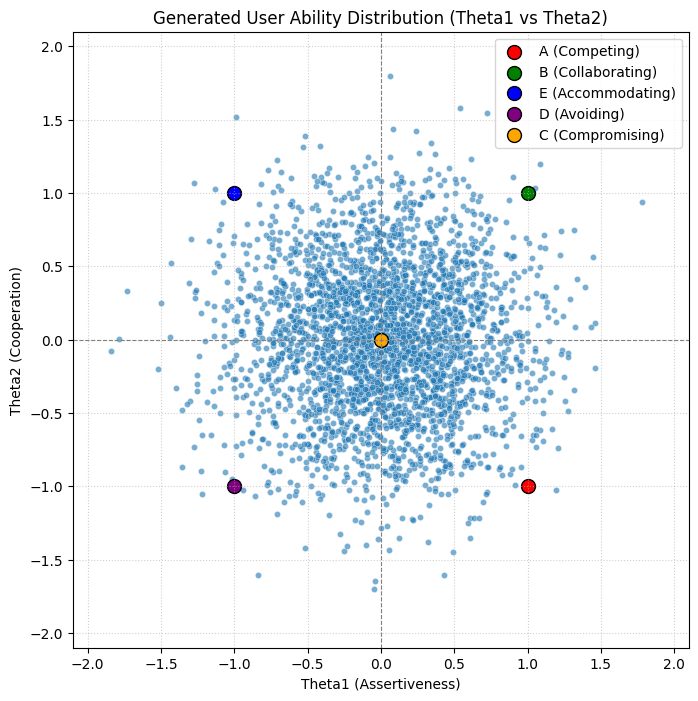

In [3]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=user_theta_coords[:, 0], y=user_theta_coords[:, 1], alpha=0.6, s=20)

# TKIのカテゴリ中心点をプロット (任意)
plt.scatter(A_coord[0], A_coord[1], color='red', marker='o', s=100, label='A (Competing)', edgecolors='black')
plt.scatter(B_coord[0], B_coord[1], color='green', marker='o', s=100, label='B (Collaborating)', edgecolors='black')
plt.scatter(E_coord[0], E_coord[1], color='blue', marker='o', s=100, label='E (Accommodating)', edgecolors='black')
plt.scatter(D_coord[0], D_coord[1], color='purple', marker='o', s=100, label='D (Avoiding)', edgecolors='black')
plt.scatter(C_coord[0], C_coord[1], color='orange', marker='o', s=100, label='C (Compromising)', edgecolors='black')

# 軸のラベルとタイトル
plt.title('Generated User Ability Distribution (Theta1 vs Theta2)')
plt.xlabel('Theta1 (Assertiveness)')
plt.ylabel('Theta2 (Cooperation)')

# TKIの象限境界線
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# 軸の範囲をTKIの範囲に合わせる
plt.xlim(ABILITY_CLIP_RANGE[0] - 0.1, ABILITY_CLIP_RANGE[1] + 0.1)
plt.ylim(ABILITY_CLIP_RANGE[0] - 0.1, ABILITY_CLIP_RANGE[1] + 0.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box') # アスペクト比を1:1に設定
plt.show()

# --- ここまで追加する可視化コード ---

# (項目応答の生成、DataFrameの作成、その他の可視化などは、この後続きます)

#回答生成

関数定義

In [4]:
def logistic_function(theta, a, b):
    """2-parameter logistic function."""
    # Ensure theta is treated as a numpy array for element-wise operations
    theta = np.asarray(theta)
    return 1 / (1 + np.exp(-a * (theta - b)))

def logistic_function_central_item(distance, a_val, b_val):
    """
    中心型項目に対する正答確率を計算（能力が中心から離れるほど確率が下がる）。
    distance: ユーザーの中心からの距離
    a_val: 識別力（正の値、カーブの急峻さ）
    b_val: 中心からの距離がこの値の時に確率が50%になる閾値
    """
    # 距離がb_valより小さいほど確率が高くなるようにする
    return 1 / (1 + np.exp(a_val * (distance - b_val)))

In [5]:
def get_projected_theta(user_coord, target_start_coord, target_end_coord):
    """
    ユーザーの能力点を、2つのターゲット点を結ぶ線分（軸）に正射影し、
    その軸上での能力値を返す。軸の始点を0とし、終点に向かう方向を正とする。
    最終的なthetaは [-1, 1] の範囲に正規化されることを想定。
    """
    axis_vector = target_end_coord - target_start_coord
    norm_axis_vector = np.linalg.norm(axis_vector)

    if norm_axis_vector == 0: # 始点と終点が同じ場合は0を返す
        return 0.0

    # ユーザーの座標を軸の始点からの相対位置として扱う
    relative_user_coord = user_coord - target_start_coord

    # 軸の単位ベクトル
    unit_axis_vector = axis_vector / norm_axis_vector
    return np.dot(user_coord, unit_axis_vector)

In [6]:
def generate_user_responses(num_users, user_coords, item_definitions):
    """
    ユーザーの応答を生成するメイン関数。
    """
    responses = np.zeros((num_users, len(item_definitions)))

    # Iterate through each item definition to calculate probabilities and responses
    for item_idx, item_def in enumerate(item_definitions):
        item_id = item_def['id']
        item_type = item_def['type']
        true_a = item_def['true_a']
        true_b = item_def['true_b']

        projected_thetas = np.zeros(num_users)
        probabilities = np.zeros(num_users)
        target_start = item_def['target_vector_start']
        target_end = item_def['target_vector_end']

            # 各ユーザーについて軸への射影を計算
        for i in range(num_users):
            projected_thetas[i] = get_projected_theta(user_coords[i], target_start, target_end)

        probabilities = logistic_function(projected_thetas, true_a, true_b)

        # 確率をクリッピングして数値的な問題を回避
        probabilities = np.clip(probabilities, 0.001, 0.999)

        # 確率に従って応答を生成 (0 or 1)
        responses[:, item_idx] = (np.random.rand(num_users) < probabilities).astype(int)

    return responses


In [7]:

# --- Item Characteristics Definition (10種類の軸 x 各3項目 = 30項目) ---
item_definitions = []
item_idx = 1 # Q1からスタート

# 1. A項目 (競争): C -> A (高主張, 低協調)
for _ in range(3):
    item_definitions.append({
        'id': f'Q{item_idx}',
        'type': 'A項目 (競争)',
        'target_vector_start': C_coord,
        'target_vector_end': A_coord,
        'true_b': np.random.uniform(0.499, 0.501), # CからAへ向かう軸でAに近いほど高確率
        'true_a': np.random.uniform(6.00, 6.01),
        'option_map': {1: 'A', 0: 'C'} # ★追加: 1がA、0がCに対応
    })
    item_idx += 1

# 2. B項目 (協調): C -> B (高主張, 高協調)
for _ in range(3):
    item_definitions.append({
        'id': f'Q{item_idx}',
        'type': 'B項目 (協調)',
        'target_vector_start': C_coord,
        'target_vector_end': B_coord,
        'true_b': np.random.uniform(0.499, 0.501), # CからBへ向かう軸でBに近いほど高確率
        'true_a': np.random.uniform(6.00, 6.01),
        'option_map': {1: 'B', 0: 'C'} # ★追加: 1がA、0がCに対応
    })
    item_idx += 1

# 3. D項目 (回避): C -> D (低主張, 低協調)
for _ in range(3):
    item_definitions.append({
        'id': f'Q{item_idx}',
        'type': 'D項目 (回避)',
        'target_vector_start': C_coord,
        'target_vector_end': D_coord,
        'true_b': np.random.uniform(0.499, 0.501), # CからDへ向かう軸でDに近いほど高確率
        'true_a': np.random.uniform(6.00, 6.01),
        'option_map': {1: 'D', 0: 'C'} # ★追加: 1がA、0がCに対応
    })
    item_idx += 1

# 4. E項目 (受容): C -> E (低主張, 高協調)
for _ in range(3):
    item_definitions.append({
        'id': f'Q{item_idx}',
        'type': 'E項目 (受容)',
        'target_vector_start': C_coord,
        'target_vector_end': E_coord,
        'true_b': np.random.uniform(0.499, 0.501), # CからEへ向かう軸でEに近いほど高確率
        'true_a': np.random.uniform(6.00, 6.01),
        'option_map': {1: 'E', 0: 'C'} # ★追加: 1がA、0がCに対応
    })
    item_idx += 1

# 5. C項目 (妥協): 中心からの距離ベース
# for _ in range(3):
#     item_definitions.append({
#         'id': f'Q{item_idx}',
#         'type': 'C項目',
#         'target_vector_start': C_coord, # ダミー、実際には使わないが、定義の一貫性のため保持
#         'target_vector_end': C_coord,   # ダミー、実際には使わない
#         'true_b': np.random.uniform(0.2, 0.5), # 距離がこれ以下の時に高確率（中心に集まる）
#         'true_a': np.random.uniform(4.0, 6.0) # 中心付近で鋭く弁別
#     })
#     item_idx += 1
# 5. 主張性軸 (+X方向): E(-1,1) → B(1,1)
for _ in range(3):
    item_definitions.append({
        'id': f'Q{item_idx}',
        'type': '主張性軸',
        'target_vector_start': E_coord,
        'target_vector_end': B_coord,
        'true_b': np.random.uniform(-0.002, 0.002), # 軸の中央付近で弁別
        'true_a': np.random.uniform(2.750, 2.751),
        'option_map': {1: 'B', 0: 'E'} # ★追加: この軸ではBが1、Eが0に対応すると仮定
    })
    item_idx += 1
# 6. 主張性軸 (+X方向): D(-1,-1) → A(1,-1)
for _ in range(3):
    item_definitions.append({
        'id': f'Q{item_idx}',
        'type': '主張性軸',
        'target_vector_start': D_coord,
        'target_vector_end': A_coord,
        'true_b': np.random.uniform(-0.002, 0.002), # 軸の中央付近で弁別
        'true_a': np.random.uniform(2.750, 2.751),
        'option_map': {1: 'A', 0: 'D'} # ★追加: この軸ではBが1、Eが0に対応すると仮定
    })
    item_idx += 1

# 7. 協調性軸 (+Y方向): A(1,-1) → B(1,1)
for _ in range(3):
    item_definitions.append({
        'id': f'Q{item_idx}',
        'type': '協調性軸',
        'target_vector_start': A_coord,
        'target_vector_end': B_coord,
        'true_b': np.random.uniform(-0.002, 0.002), # 軸の中央付近で弁別
        'true_a': np.random.uniform(2.750, 2.751),
        'option_map': {1: 'B', 0: 'A'} # ★追加: この軸ではBが1、Eが0に対応すると仮定
    })
    item_idx += 1

# 10. D-E 軸 (低主張側での協調性): D(-1,-1) → E(-1,1)
for _ in range(3):
    item_definitions.append({
        'id': f'Q{item_idx}',
        'type': 'D-E軸',
        'target_vector_start': D_coord,
        'target_vector_end': E_coord,
        'true_b': np.random.uniform(-0.002, 0.002), # 軸の中央付近で弁別
        'true_a': np.random.uniform(2.750, 2.751),
        'option_map': {1: 'E', 0: 'D'} # ★追加: この軸ではBが1、Eが0に対応すると仮定
    })
    item_idx += 1

# 8. A-E 対角軸 (競合vs受容): E(-1,1) → A(1,-1)
for _ in range(3):
    item_definitions.append({
        'id': f'Q{item_idx}',
        'type': 'A-E対角軸',
        'target_vector_start': E_coord,
        'target_vector_end': A_coord,
        'true_b': np.random.uniform(-0.002, 0.002), # A側寄りで弁別
        'true_a': np.random.uniform(2.750, 2.751),
        'option_map': {1: 'A', 0: 'E'} # ★追加: この軸ではBが1、Eが0に対応すると仮定
    })
    item_idx += 1

# 9. B-D 対角軸 (協調vs回避): D(-1,-1) → B(1,1)
for _ in range(3):
    item_definitions.append({
        'id': f'Q{item_idx}',
        'type': 'B-D対角軸',
        'target_vector_start': D_coord,
        'target_vector_end': B_coord,
        'true_b': np.random.uniform(0.0, 0.4), # B側寄りで弁別
        'true_a': np.random.uniform(2.0, 3.5),
        'option_map': {1: 'B', 0: 'D'} # ★追加: この軸ではBが1、Eが0に対応すると仮定
    })
    item_idx += 1


# --- Double check total items ---
if len(item_definitions) != 30:
    print(f"Warning: Total items defined is {len(item_definitions)}, not 30. Please adjust item definitions.")


In [8]:

# --- Generate Responses ---
responses_array = generate_user_responses(NUM_USERS, user_theta_coords, item_definitions)
print(responses_array)
# Convert responses to DataFrame for easier handling
responses_df = pd.DataFrame(responses_array, columns=[item['id'] for item in item_definitions])
print(responses_df)
responses_df_char = pd.DataFrame(index=responses_df.index, columns=responses_df.columns)

for item_def in item_definitions:
    q_id = item_def['id']
    option_map = item_def['option_map'] # 定義したoption_mapを取得

    # responses_df の数値（0または1）を対応する文字列に変換
    # map() メソッドを使って辞書を適用
    responses_df_char[q_id] = responses_df[q_id].map(option_map)

# これが、フォームの回答と同じ形式のDataFrameになります
#responses_df = responses_df_char.copy()
# --- Calculate Aggregated Scores (TKI Styles) ---
possible_answers = ['A', 'B', 'C', 'D', 'E']
# 各スタイルに対応する項目IDを定義
# ここが最も重要な修正点です。item_definitionsに基づいて正確にマッピングします。
# 例: 'A項目 (競争)' のIDをリストアップする
competing_items = [item['id'] for item in item_definitions if 'A項目 (競争)' in item['type']]
collaborating_items = [item['id'] for item in item_definitions if 'B項目 (協調)' in item['type']]
avoiding_items = [item['id'] for item in item_definitions if 'D項目 (回避)' in item['type']]
accommodating_items = [item['id'] for item in item_definitions if 'E項目 (受容)' in item['type']]

# 妥協 (Compromising) は、通常、他のスタイルの組み合わせや中心的な項目で評価されます。
# ここでは、C項目として定義された項目を集計すると仮定します。
# もしC項目が存在しない場合、この行は削除するか、他の方法で妥協点を定義する必要があります。
compromising_items = [item['id'] for item in item_definitions if 'C項目' in item['type']] # もしC項目があれば
for item_style in possible_answers:
    # 各ユーザーについて、Q1～Q30の列の中でそのスタイル（例: 'A'）が何回出現したかをカウント
    # axis=1 で行方向（ユーザーごと）にカウントします
    responses_df_char[f'{item_style}_Score'] = responses_df_char[[f'Q{i+1}' for i in range(30)]].apply(
        lambda row: (row == item_style).sum(), axis=1
    )
# responses_df_char['Competing_Score'] = responses_df[competing_items].sum(axis=1)
# responses_df_char['Collaborating_Score'] = responses_df[collaborating_items].sum(axis=1)
# responses_df_char['avoiding_Score'] = responses_df[avoiding_items].sum(axis=1)
# responses_df_char['accomodating_Score'] = responses_df[accommodating_items].sum(axis=1)
# responses_df_char['Compromising_Score'] = responses_df[compromising_items].sum(axis=1)
# # 同様に他のスタイルも計算
print(responses_df_char)


[[0. 1. 1. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 1. 0.]
 [0. 0. 0. ... 0. 1. 1.]]
       Q1   Q2   Q3   Q4   Q5   Q6   Q7   Q8   Q9  Q10  ...  Q21  Q22  Q23  \
0     0.0  1.0  1.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  ...  1.0  1.0  1.0   
1     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  1.0  0.0   
3     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
4     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  1.0   
...   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
2995  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0  0.0  ...  0.0  0.0  0.0   
2996  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  1.0  1.0  1.0   
2997  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  1.0  ...  1.0  0.0  1.0   
2998  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  ...  1.0

In [9]:


# --- Q列の元のA～E文字列から、対応する0または1の数値データを内部的に準備 ---
# ここが重要です。responses_dfがA～Eの文字列なので、
# 軸の重心計算のために、各質問の回答を0か1に変換した「数値版のresponses_data」が必要です。
# この変換ロジックは、item_definitionと、どの選択肢が0でどの選択肢が1に対応するかに依存します。
# 例として、特定の軸（例: AC軸）の質問（Q1, Q2, Q3）に対して、
# Aを1、Cを0、その他（B, D, E）をNaNと変換するマッピングを定義します。

# 全ての質問の回答を数値に変換するための関数を準備
# def convert_response_to_numeric(response_str, axis_name, axis_value_map):
#     if axis_name in axis_value_map:
#         mapping = axis_value_map[axis_name]
#         return mapping.get(response_str, np.nan) # マッピングにない場合はNaN
#     return np.nan # 軸情報がない場合もNaN

# 軸名と対応する質問リストの辞書 (前回のものと同一)
num_users=NUM_USERS
axis_question_map = {
     'AC': ['Q1', 'Q2', 'Q3'], 'BC': ['Q4', 'Q5', 'Q6'], 'DC': ['Q7', 'Q8', 'Q9'],
     'EC': ['Q10', 'Q11', 'Q12'], 'BE': ['Q13', 'Q14', 'Q15'], 'AD': ['Q16', 'Q17', 'Q18'],
     'AB': ['Q19', 'Q20', 'Q21'], 'DE': ['Q22', 'Q23', 'Q24'], 'AE': ['Q25', 'Q26', 'Q27'],
     'BD': ['Q28', 'Q29', 'Q30'],
 }

# # 各軸における選択肢の数値マッピングルール (前回のものと同一)
# axis_value_map = {
#     'AC': {'A': 1, 'C': 0}, 'BC': {'B': 1, 'C': 0}, 'DC': {'D': 1, 'C': 0},
#     'EC': {'E': 1, 'C': 0}, 'BE': {'B': 1, 'E': 0}, 'AD': {'A': 1, 'D': 0},
#     'AB': {'A': 1, 'B': 0}, 'DE': {'D': 1, 'E': 0}, 'AE': {'A': 1, 'E': 0},
#     'BD': {'B': 1, 'D': 0},
# }

# # responses_dfのコピーを作成し、数値を格納するためのDataFrameを準備
# # Q列が数値に変換されたDataFrameとして使用します。
# responses_numeric_for_centroid = pd.DataFrame(index=responses_df.index, columns=responses_df.columns)

# # 各Q列の回答を数値に変換して responses_numeric_for_centroid に格納
# for q_col in responses_df.columns: # Q1, Q2, ..., Q30をループ
#     found_axis = None
#     for axis_name, q_cols_in_map in axis_question_map.items():
#         if q_col in q_cols_in_map:
#             found_axis = axis_name
#             break

#     if found_axis:
#         responses_numeric_for_centroid[q_col] = responses_df[q_col].apply(
#             lambda x: convert_response_to_numeric(x, found_axis, axis_value_map)
#         )
#     else:
#         # 軸にマッピングされていないQ列がある場合はそのままNaNにするか、適切に処理
#         responses_numeric_for_centroid[q_col] = np.nan # ここは質問外のQ列用、本来は発生しないはず


# print("内部で使用する数値変換された応答データ (responses_numeric_for_centroid):")
# print(responses_numeric_for_centroid.head())
# print("-" * 50)


# # --- 1. A～Eの集計列の追加（responses_dfは文字列なのでそのまま適用） ---
# for item in possible_answers:
#     responses_df[item] = responses_df.apply(lambda row: (row == item).sum(), axis=1)

# print("\nA～Eの集計列が追加された responses_df (文字列データ):")
# print(responses_df.head())
# print("-" * 50)

# # --- 2. 各軸の回答重心（平均値）の計算 ---
# # responses_numeric_for_centroid から数値を拾って平均を計算し、responses_dfに追加
# for axis_name, q_cols in axis_question_map.items():
#     # responses_numeric_for_centroid の該当するQ列の平均を計算
#     responses_df[axis_name] = responses_numeric_for_centroid[q_cols].mean(axis=1)

# print("\n組み合わせ軸の集計列（回答重心）が追加された responses_df:")
# print(responses_df.head())
# print("-" * 50)

# --- 3. ダミーのタイムスタンプとユーザーIDの追加 ---
# `insert()` メソッドを使って、DataFrameの先頭に列を追加します。

for axis_name, q_cols in axis_question_map.items():
    # responses_df の該当するQ列の平均を計算 (既に0/1の数値データなのでそのまま使える)
    responses_df_char[axis_name] = responses_df[q_cols].mean(axis=1)
responses_df_char.insert(0, 'User_ID', range(1, num_users + 1))
responses_df_char.insert(1, 'Timestamp', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

print("\nIDとタイムスタンプが追加された最終的な DataFrame:")
print(responses_df.head())
print("-" * 50)

# --- 4. Excel出力 ---
output_excel_file = 'dummytki.xlsx'
sheet_name = 'フォームの回答 1' # ここでシート名を定義します
responses_df_char.to_excel(output_excel_file, index=False)

print(f"\nDataFrame が '{output_excel_file}' として Excel 出力されました。Colab の左側のファイルタブで確認してください。")

df1_last_15_cols = responses_df_char.iloc[:, -15:]
print(df1_last_15_cols)
df_processed = pd.concat([responses_df, df1_last_15_cols], axis=1)
print(df_processed)


IDとタイムスタンプが追加された最終的な DataFrame:
    Q1   Q2   Q3   Q4   Q5   Q6   Q7   Q8   Q9  Q10  ...  Q21  Q22  Q23  Q24  \
0  0.0  1.0  1.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  ...  1.0  1.0  1.0  0.0   
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  1.0   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  1.0  0.0  1.0   
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  1.0   
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  1.0  0.0   

   Q25  Q26  Q27  Q28  Q29  Q30  
0  1.0  1.0  1.0  0.0  1.0  0.0  
1  1.0  1.0  0.0  0.0  0.0  0.0  
2  1.0  1.0  1.0  0.0  1.0  0.0  
3  1.0  1.0  1.0  0.0  0.0  0.0  
4  0.0  1.0  1.0  0.0  0.0  0.0  

[5 rows x 30 columns]
--------------------------------------------------

DataFrame が 'dummytki.xlsx' として Excel 出力されました。Colab の左側のファイルタブで確認してください。
      A_Score  B_Score  C_Score  D_Score  E_Score        AC        BC  \
0           7        8        9        4        2  0.666667  

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.impute import SimpleImputer
import warnings
from google.colab import files
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler

In [11]:
imputer = SimpleImputer(strategy='mean')
question_data=df_processed.iloc[:, 0:29]
question_data = question_data.apply(pd.to_numeric, errors='coerce')
question_data_imputed = pd.DataFrame(imputer.fit_transform(question_data), columns=question_data.columns)

# カテゴリ集計データ (df_processedの30列目から34列目, Pythonインデックスでは29列目から33列目)
# df_processedのインデックスは0から始まるため、30番目から34番目の列（アンケート数により、指定は変わる）
catg_aggregated_data = df_processed.iloc[:, 30:35]
catg_aggregated_data = catg_aggregated_data.apply(pd.to_numeric, errors='coerce')
catg_aggregated_data_imputed = pd.DataFrame(imputer.fit_transform(catg_aggregated_data), columns=catg_aggregated_data.columns)
print(f"カテゴリ集計データの欠損値を平均値で補完しました。補完後の形状: {catg_aggregated_data_imputed.shape}")

# 重心計算データ (df_processedの35列目から44列目, Pythonインデックスでは34列目から43列目)
# df_processedのインデックスは0から始まるため、35番目から44番目の列
centroid_data = df_processed.iloc[:, 35:45]
centroid_data = centroid_data.apply(pd.to_numeric, errors='coerce')
centroid_data_imputed = pd.DataFrame(imputer.fit_transform(centroid_data), columns=centroid_data.columns)
print(f"重心計算データの欠損値を平均値で補完しました。補完後の形状: {centroid_data_imputed.shape}")
# --- ★追加: catg集計データと重心計算データの列名ラベル付け ---
# catg集計データの列名変更
catg_aggregated_data_imputed.columns = ['A', 'B', 'C', 'D', 'E'] # ★追加
print("\ncatg集計データの列名を ['A', 'B', 'C', 'D', 'E'] に変更しました。")

# 重心計算データの列名変更
centroid_labels = ['BA', 'BC', 'BD', 'BE', 'ED', 'EC', 'EA', 'AC', 'DC', 'AD'] # ★追加
if len(centroid_labels) == centroid_data_imputed.shape[1]: # 列数とラベル数が一致するか確認
    centroid_data_imputed.columns = centroid_labels # ★追加
    print(f"重心計算データの列名を {centroid_labels} に変更しました。")
else:
    print("警告: 重心計算データの列数と指定されたラベル数が一致しません。列名変更をスキップしました。") # ★追加

# 全てのデータでスケールを統一 (PCAやFAの前に重要)
scaler = StandardScaler()
question_data_scaled = scaler.fit_transform(question_data_imputed)
#catg_aggregated_data_scaled = scaler.fit_transform(catg_aggregated_data_imputed)
#centroid_data_scaled = scaler.fit_transform(centroid_data_imputed)
catg_aggregated_data_scaled = scaler.fit_transform(catg_aggregated_data_imputed) # 列名が変更されたDataFrameを渡す
centroid_data_scaled = scaler.fit_transform(centroid_data_imputed) # 列名が変更されたDataFrameを渡す

# データフレームに戻す（列名を保持するため）
question_data_scaled_df = pd.DataFrame(question_data_scaled, columns=question_data_imputed.columns)
catg_aggregated_data_scaled_df = pd.DataFrame(catg_aggregated_data_scaled, columns=catg_aggregated_data_imputed.columns)
centroid_data_scaled_df = pd.DataFrame(centroid_data_scaled, columns=centroid_data_imputed.columns)

カテゴリ集計データの欠損値を平均値で補完しました。補完後の形状: (3000, 5)
重心計算データの欠損値を平均値で補完しました。補完後の形状: (3000, 10)

catg集計データの列名を ['A', 'B', 'C', 'D', 'E'] に変更しました。
重心計算データの列名を ['BA', 'BC', 'BD', 'BE', 'ED', 'EC', 'EA', 'AC', 'DC', 'AD'] に変更しました。


In [19]:
# --- 3. PCAの実行と可視化 ---

def run_pca_and_plot(data_df, title_prefix):
    """PCAを実行し、固有値プロットとbiplotを生成する関数"""
    print(f"\n--- {title_prefix} PCA分析 ---")
    pca = PCA()
    pca.fit(data_df)

    # 固有値（分散説明率）のプロット
    plt.figure(figsize=(10, 6))
    plt.plot((pca.explained_variance_ratio_))#各バリアンスの値を直接プロットしたい場合。ここと下のどちらかを使うと良い。
#    plt.plot(np.cumsum(pca.explained_variance_ratio_))#累積値で見たい時用。
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title(f'{title_prefix} Cumulative Explained Variance by Principal Components')
    plt.grid(True)
    plt.show()

    # 個別の寄与率も確認
    print(f"{title_prefix} Explained Variance Ratio per Component:")
    for i, ratio in enumerate(pca.explained_variance_ratio_):
        print(f"  PC{i+1}: {ratio:.4f} (Cumulative: {np.cumsum(pca.explained_variance_ratio_)[i]:.4f})")
    print(pca.components_)
    # 最初の3主成分でのbiplot
    pca_result = PCA(n_components=3) #
    components = pca_result.fit_transform(data_df)
    loadings = pca_result.components_.T * np.sqrt(pca_result.explained_variance_) #  3成分の負荷量を取得
    fig, axes = plt.subplots(1, 3, figsize=(24, 8)) # ★修正: 1行3列のサブプロットを作成
    plot_combinations = [(0, 1, '1st vs 2nd'), (0, 2, '1st vs 3rd'), (1, 2, '2nd vs 3rd')] # ★追加
    for idx, (pc_x, pc_y, title_suffix) in enumerate(plot_combinations): # ★追加
        ax = axes[idx] # ★追加: 現在のサブプロット軸を選択
        sns.scatterplot(x=components[:, pc_x], y=components[:, pc_y], alpha=0.6, ax=ax) # ★修正: axを指定
        for i, feature in enumerate(data_df.columns):
            arrow_length = np.sqrt(loadings[i, pc_x]**2 + loadings[i, pc_y]**2) # ★修正: 該当する軸の負荷量を使用
            if arrow_length > 0:
                scale_factor = min(np.max(np.abs(components[:, [pc_x, pc_y]])) / np.max(np.abs(loadings[:, [pc_x, pc_y]])), 1.0) * 0.8
                ax.arrow(0, 0, loadings[i, pc_x] * scale_factor, loadings[i, pc_y] * scale_factor, # ★修正: ax.arrowを使用
                          color='r', alpha=0.7, head_width=0.05 * np.max(np.abs(components[:, [pc_x, pc_y]])))
                ax.text(loadings[i, pc_x] * scale_factor * 1.15, loadings[i, pc_y] * scale_factor * 1.15, # ★修正: ax.textを使用
                         feature, color='g', ha='center', va='center', fontsize=9)

        ax.set_xlabel(f'Principal Component {pc_x+1} ({pca_result.explained_variance_ratio_[pc_x]*100:.2f}%)') # ★修正
        ax.set_ylabel(f'Principal Component {pc_y+1} ({pca_result.explained_variance_ratio_[pc_y]*100:.2f}%)') # ★修正
        ax.set_title(f'{title_prefix} PCA Biplot ({title_suffix} Components)') # ★修正
        ax.axhline(0, color='grey', lw=0.5) # ★修正: ax.axhlineを使用
        ax.axvline(0, color='grey', lw=0.5) # ★修正: ax.axvlineを使用
        ax.grid(True)
    plt.subplots_adjust(hspace=0.5)
    plt.tight_layout() # ★追加: サブプロット間のスペースを調整
    plt.show()

    return pca_result, components, loadings


--- catg Aggregated Data PCA分析 ---


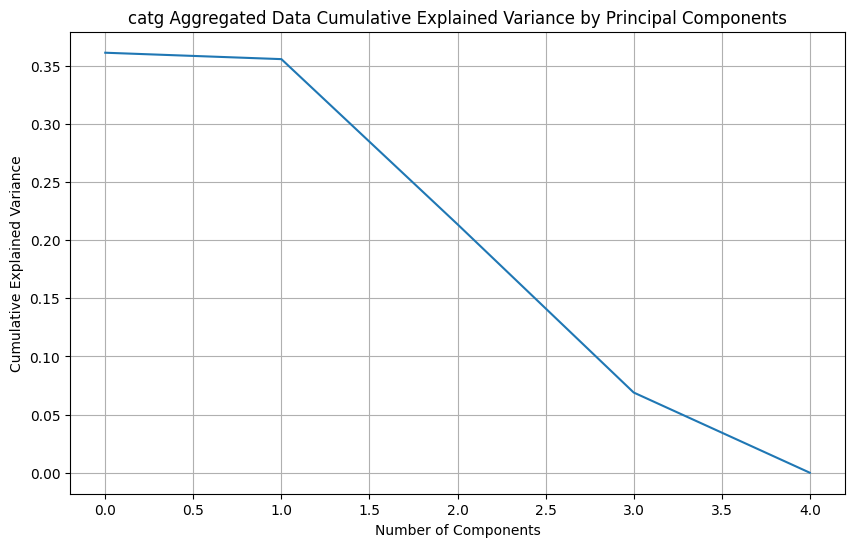

catg Aggregated Data Explained Variance Ratio per Component:
  PC1: 0.3614 (Cumulative: 0.3614)
  PC2: 0.3559 (Cumulative: 0.7172)
  PC3: 0.2137 (Cumulative: 0.9310)
  PC4: 0.0690 (Cumulative: 1.0000)
  PC5: 0.0000 (Cumulative: 1.0000)
[[ 0.58770904 -0.38970804 -0.02061551  0.39963832 -0.58531183]
 [ 0.3976689   0.59315113 -0.05941261 -0.57902575 -0.38888367]
 [-0.0877478  -0.107181    0.96387793 -0.16105861 -0.1606612 ]
 [-0.50005247  0.50295051  0.01198578  0.502526   -0.49427955]
 [ 0.48857485  0.48151053  0.25853592  0.47596864  0.48585518]]


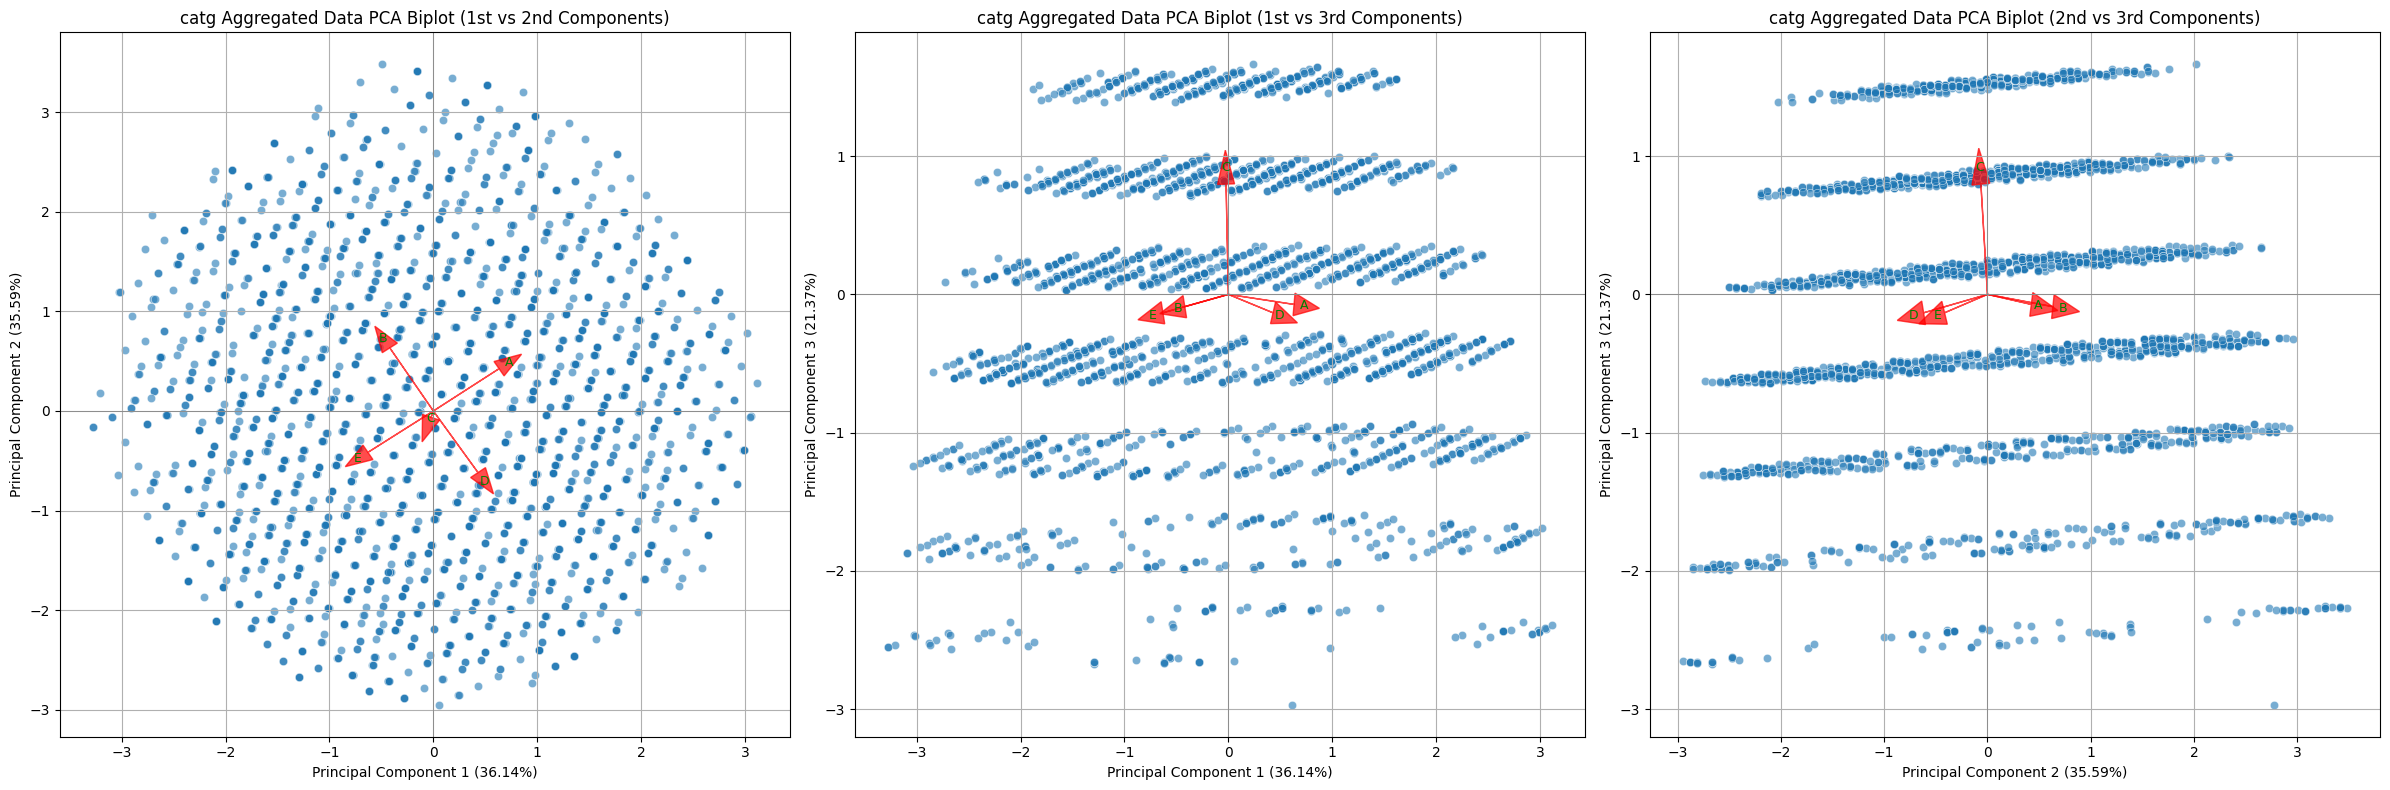


--- Centroid Data PCA分析 ---


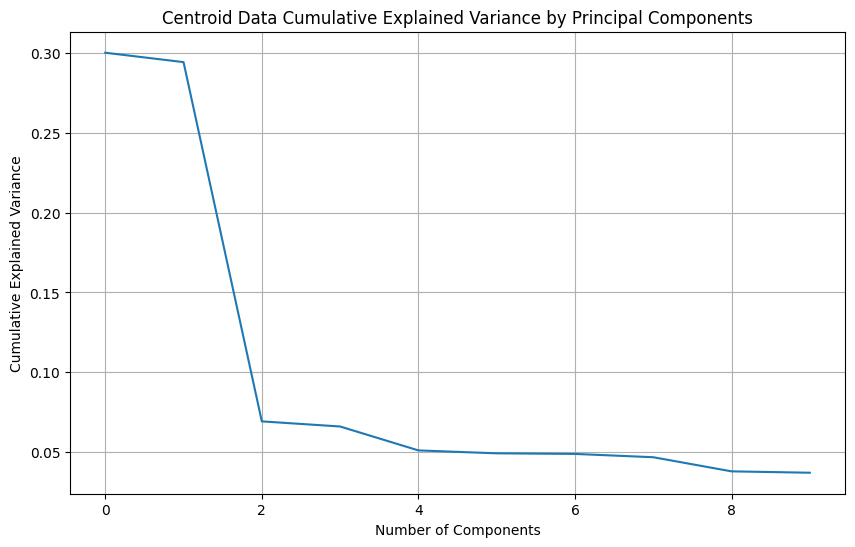

Centroid Data Explained Variance Ratio per Component:
  PC1: 0.3004 (Cumulative: 0.3004)
  PC2: 0.2945 (Cumulative: 0.5949)
  PC3: 0.0691 (Cumulative: 0.6640)
  PC4: 0.0659 (Cumulative: 0.7300)
  PC5: 0.0509 (Cumulative: 0.7809)
  PC6: 0.0491 (Cumulative: 0.8300)
  PC7: 0.0487 (Cumulative: 0.8787)
  PC8: 0.0466 (Cumulative: 0.9253)
  PC9: 0.0378 (Cumulative: 0.9631)
  PC10: 0.0369 (Cumulative: 1.0000)
[[-0.40148777  0.14288705 -0.15423152  0.4073357  -0.19515707 -0.19500625
   0.41652895  0.41850807 -0.41747466  0.17215382]
 [ 0.14735769  0.41320073 -0.39518365 -0.14718628  0.41916567  0.42015542
   0.19459195  0.19256155  0.16906885  0.41708064]
 [-0.16116888  0.60229094  0.68424801 -0.17471136 -0.03721017 -0.12042434
  -0.05172683 -0.10326038 -0.02500778  0.28757684]
 [ 0.69274728  0.15731857  0.16248697  0.66221781 -0.10095181 -0.03646498
   0.05878783 -0.01432335  0.10736437  0.0608966 ]
 [-0.11470672  0.06444622  0.0587325  -0.06939289 -0.11488492 -0.24719959
   0.36494905  0.3075

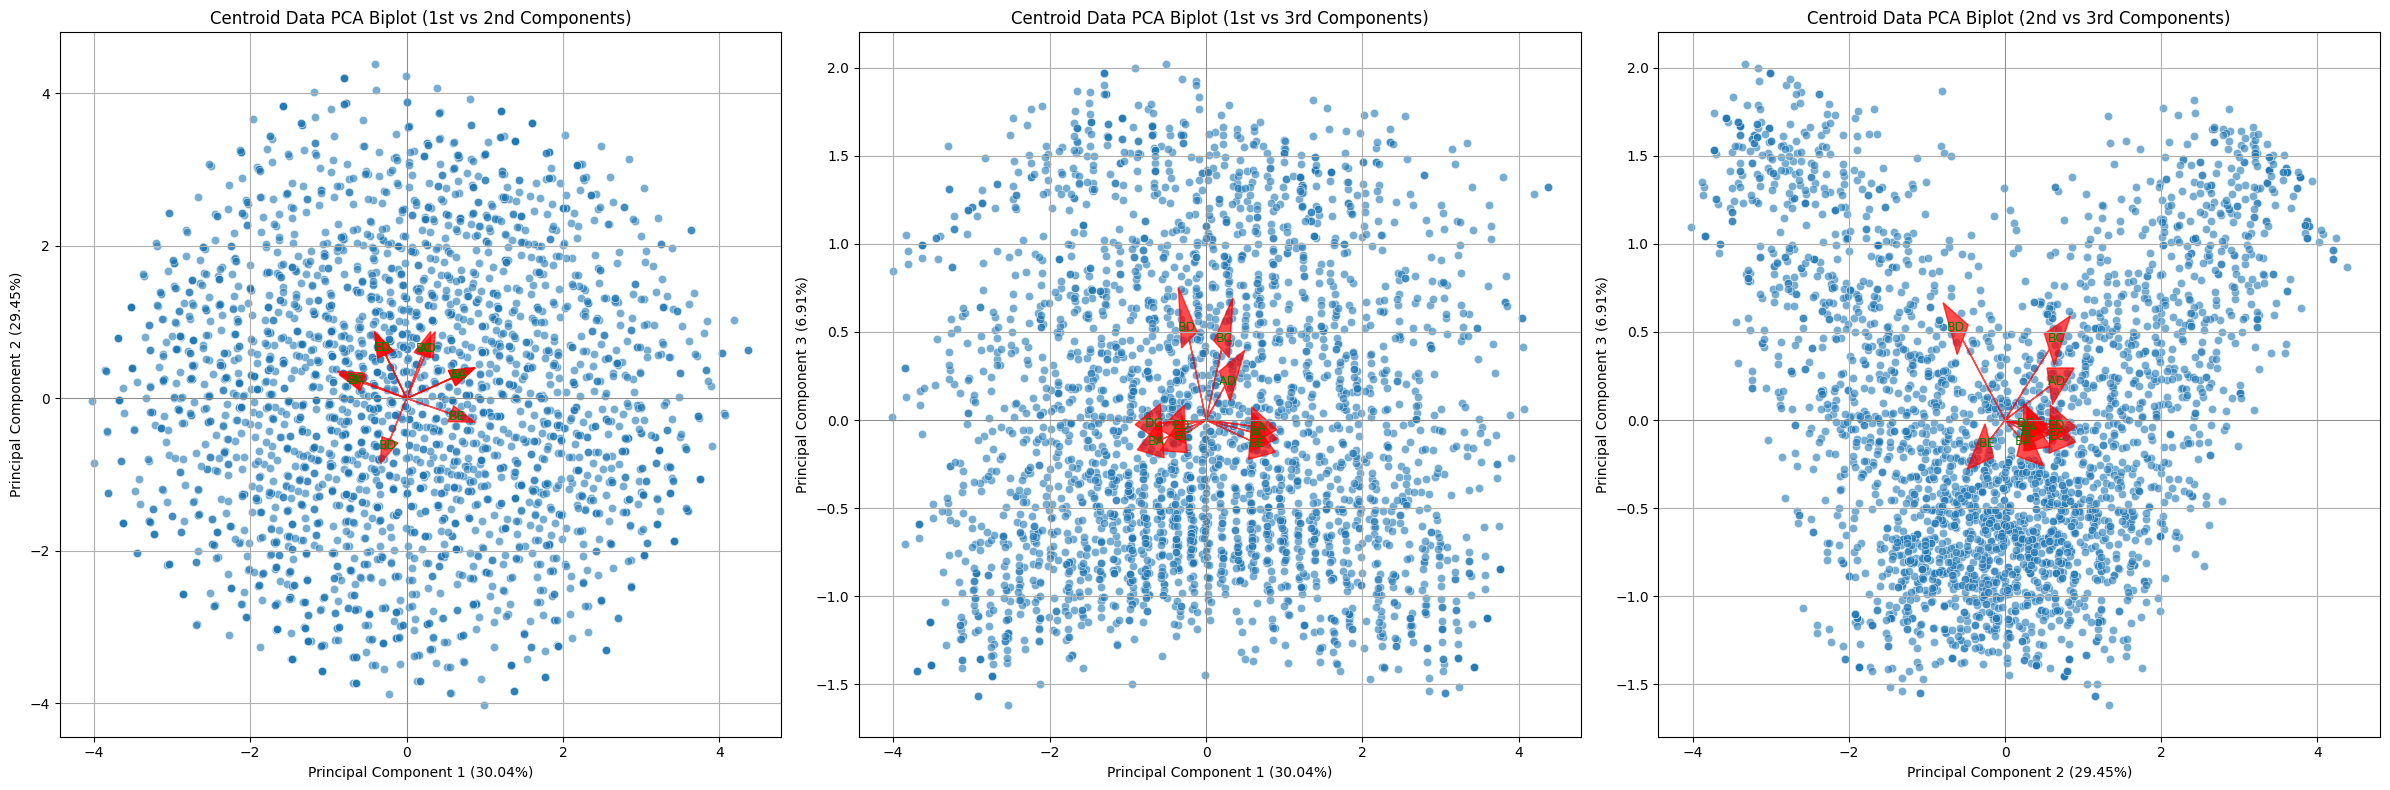

In [20]:
# catg集計データに対するPCA
pca_catg, components_catg, loadings_catg = run_pca_and_plot(catg_aggregated_data_scaled_df, "catg Aggregated Data")
#components = components_catg
# 重心計算データに対するPCA
pca_centroid, components_centroid, loadings_centroid = run_pca_and_plot(centroid_data_scaled_df, "Centroid Data")

# アンケート回答データに対するPCA (3軸の可能性検証のため)
#pca_questions, components_questions, loadings_questions = run_pca_and_plot(question_data_scaled_df, "Raw Question Data")


In [14]:
# データフレームの列名をQ1, Q2...のようにリネームすると、IRT結果が分かりやすくなります
original_question_columns = question_data_imputed.columns
question_data_imputed.columns = [f'Q{i+1}' for i in range(question_data_imputed.shape[1])]

# 簡易的な二値化: 各質問の回答がその質問の平均値より大きいか否か
binarized_question_data = (question_data_imputed > question_data_imputed.mean()).astype(int)
scaler = StandardScaler()
question_data_scaled = scaler.fit_transform(binarized_question_data)

#pcaの結果に基づく因子量計算 catg,centroid
theta_pca_catg_scores = pca_catg.fit_transform(question_data_scaled)#PCAの結果利用
#theta_pca_catg_scores = pca_centroid.fit_transform(question_data_scaled)#FAの結果を利用する場合こちら
num_col,num_questions=binarized_question_data.shape
num_bins = 10#一人で複数の問題をやっているわけではないので計算した因子量から5組に分けて、その平均得点で分析
#人数が多い場合はここの数値を上げることで精度が上がる。逆にいうと、ここを変えると結果がすごく変わる。

In [15]:
# --- 3. ロジスティック関数の定義 (2PLモデルのICC) ---
# P(theta) = c + (1 - c) / (1 + exp(-a * (theta - b)))  <- 3PLモデル
# 2PLモデルの場合 c=0 (当て推量なし)
# P(theta) = 1 / (1 + exp(-a * (theta - b)))
def logistic_icc(theta, a, b):
    # a: 識別力パラメータ (傾き)
    # b: 困難度パラメータ (平行移動)
    return 1 / (1 + np.exp(-a * (theta - b)))
question_item_names = {
   'Q1': 'AC', 'Q2': 'AC', 'Q3': 'AC', 'Q4': 'BC', 'Q5': 'BC',
    'Q6': 'BC', 'Q7': 'DC', 'Q8': 'DC', 'Q9': 'DC', 'Q10': 'EC',
   'Q11': 'EC', 'Q12': 'EC', 'Q13': 'BE', 'Q14': 'BE', 'Q15': 'BE',
   'Q16': 'AD', 'Q17': 'AD', 'Q18': 'AD', 'Q19': 'BA', 'Q20': 'BA',
   'Q21': 'BA', 'Q22': 'ED', 'Q23': 'ED', 'Q24': 'ED', 'Q25': 'AE',
   'Q26': 'AE', 'Q27': 'AE', 'Q28': 'BD', 'Q29': 'BD', 'Q30': 'BD'
}


--- PC1に対するIRT分析 ---
--- θビンごとの正答割合（一部）---
         Q1        Q2        Q3        Q4        Q5        Q6        Q7  \
0  0.980392  0.990196  0.941176  0.049020  0.107843  0.068627  0.254902   
1  0.860870  0.886957  0.852174  0.191304  0.182609  0.213043  0.191304   
2  0.532374  0.564748  0.539568  0.187050  0.187050  0.179856  0.212230   
3  0.253012  0.219277  0.240964  0.154217  0.149398  0.118072  0.236145   
4  0.070922  0.081560  0.083333  0.189716  0.187943  0.175532  0.179078   

         Q8        Q9       Q10  ...       Q21       Q22       Q23       Q24  \
0  0.245098  0.254902  0.000000  ...  0.019608  0.058824  0.058824  0.058824   
1  0.178261  0.191304  0.000000  ...  0.186957  0.195652  0.186957  0.204348   
2  0.208633  0.233813  0.003597  ...  0.233813  0.273381  0.276978  0.276978   
3  0.245783  0.197590  0.007229  ...  0.325301  0.306024  0.344578  0.296386   
4  0.182624  0.186170  0.015957  ...  0.441489  0.480496  0.466312  0.404255   

        Q25       Q26   

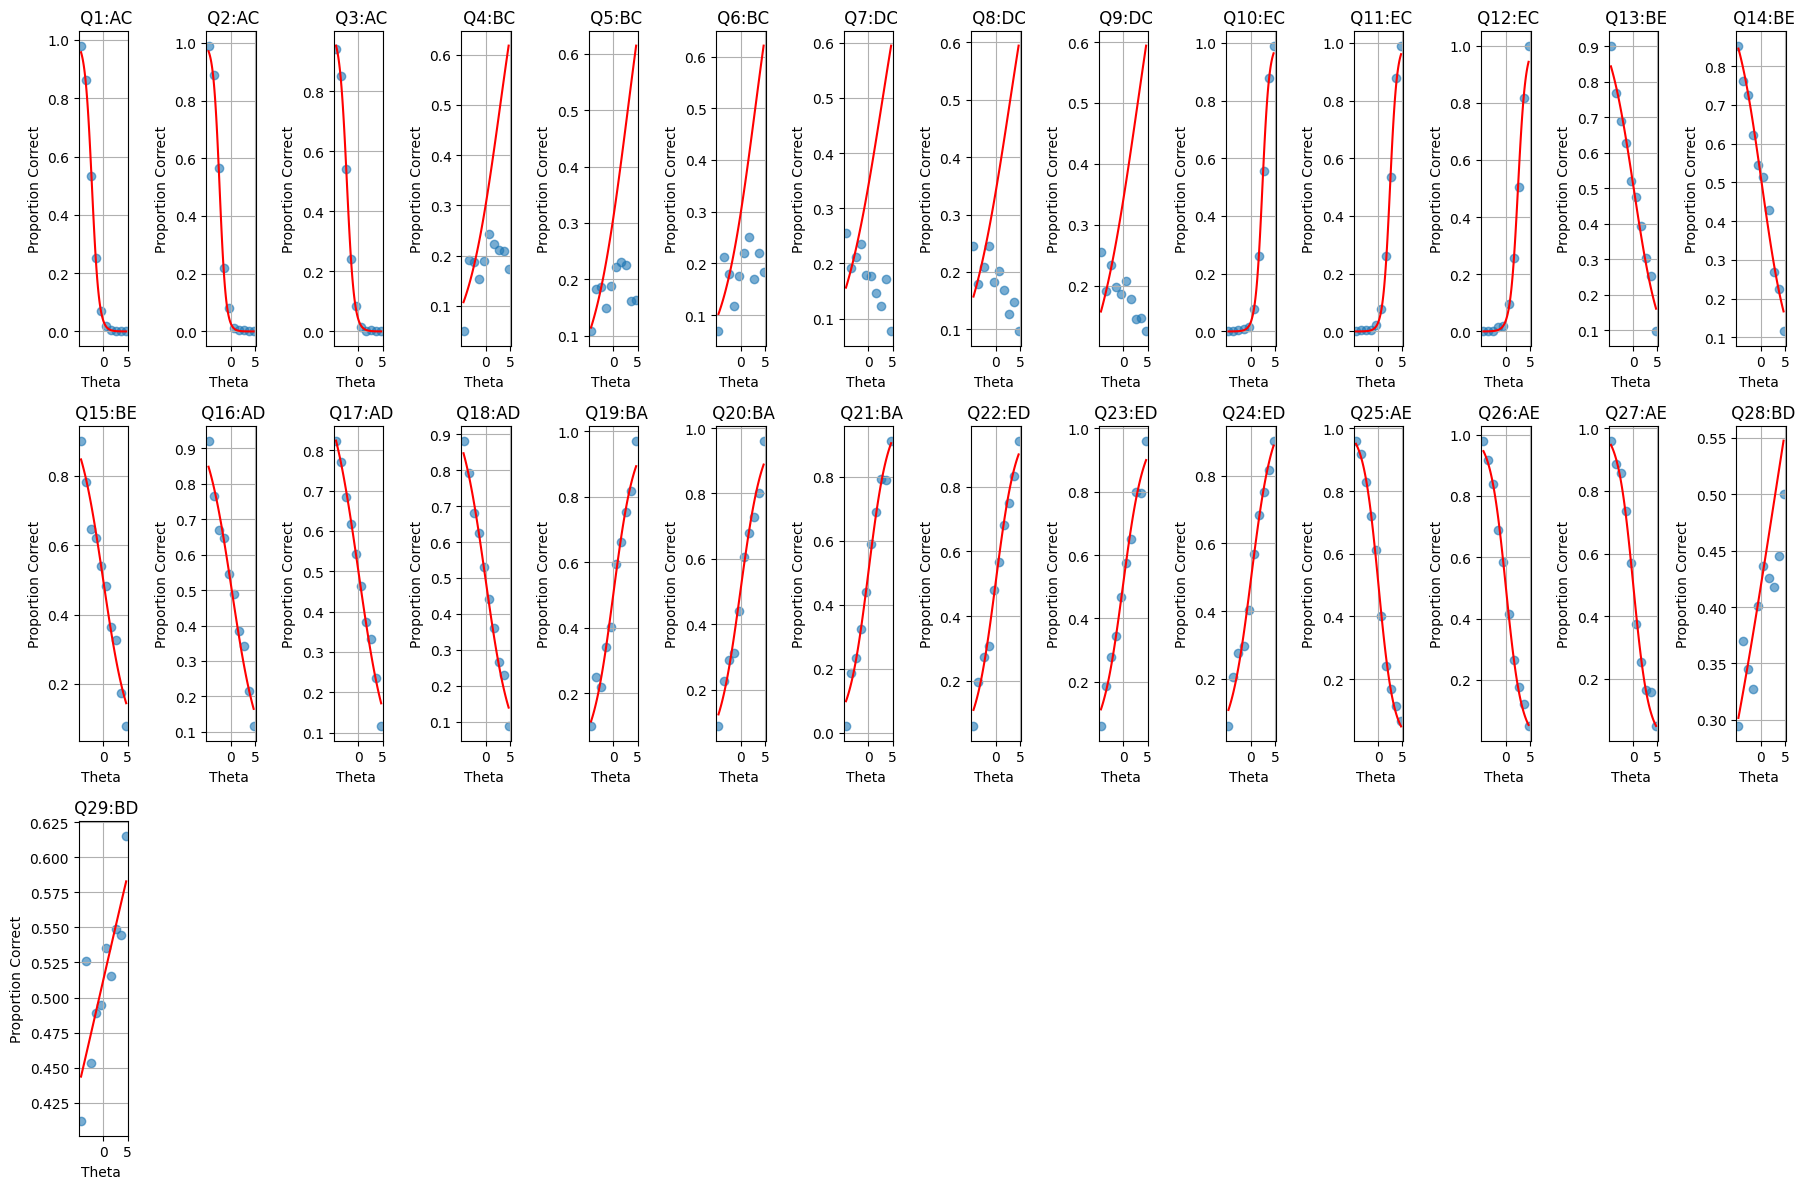


--- PC1に対する推定されたIRTパラメータ (2PL) ---
Q1:AC: a=-1.4003, b=-2.2984, R²=0.9984
Q2:AC: a=-1.5499, b=-2.2660, R²=0.9988
Q3:AC: a=-1.3487, b=-2.3129, R²=0.9993
Q4:BC: a=0.2815, b=3.0000, R²=-16.3218
Q5:BC: a=0.2716, b=3.0000, R²=-34.9598
Q6:BC: a=0.2885, b=3.0000, R²=-16.7830
Q7:DC: a=0.2240, b=3.0000, R²=-26.1246
Q8:DC: a=0.2233, b=3.0000, R²=-29.9500
Q9:DC: a=0.2226, b=3.0000, R²=-40.3106
Q10:EC: a=1.4308, b=2.4185, R²=0.9983
Q11:EC: a=1.4153, b=2.4501, R²=0.9971
Q12:EC: a=1.2942, b=2.5395, R²=0.9959
Q13:BE: a=-0.3617, b=0.1318, R²=0.9784
Q14:BE: a=-0.3577, b=0.2204, R²=0.9814
Q15:BE: a=-0.3788, b=0.0056, R²=0.9698
Q16:AD: a=-0.3616, b=0.2260, R²=0.9733
Q17:AD: a=-0.3364, b=0.0539, R²=0.9895
Q18:AD: a=-0.3828, b=-0.0524, R²=0.9882
Q19:BA: a=0.4526, b=0.0229, R²=0.9773
Q20:BA: a=0.4351, b=-0.0554, R²=0.9785
Q21:BA: a=0.4843, b=0.0468, R²=0.9851
Q22:ED: a=0.4638, b=-0.0174, R²=0.9883
Q23:ED: a=0.4614, b=-0.0547, R²=0.9841
Q24:ED: a=0.4543, b=0.1310, R²=0.9874
Q25:AE: a=-0.6413, b=0.0867, R²=0

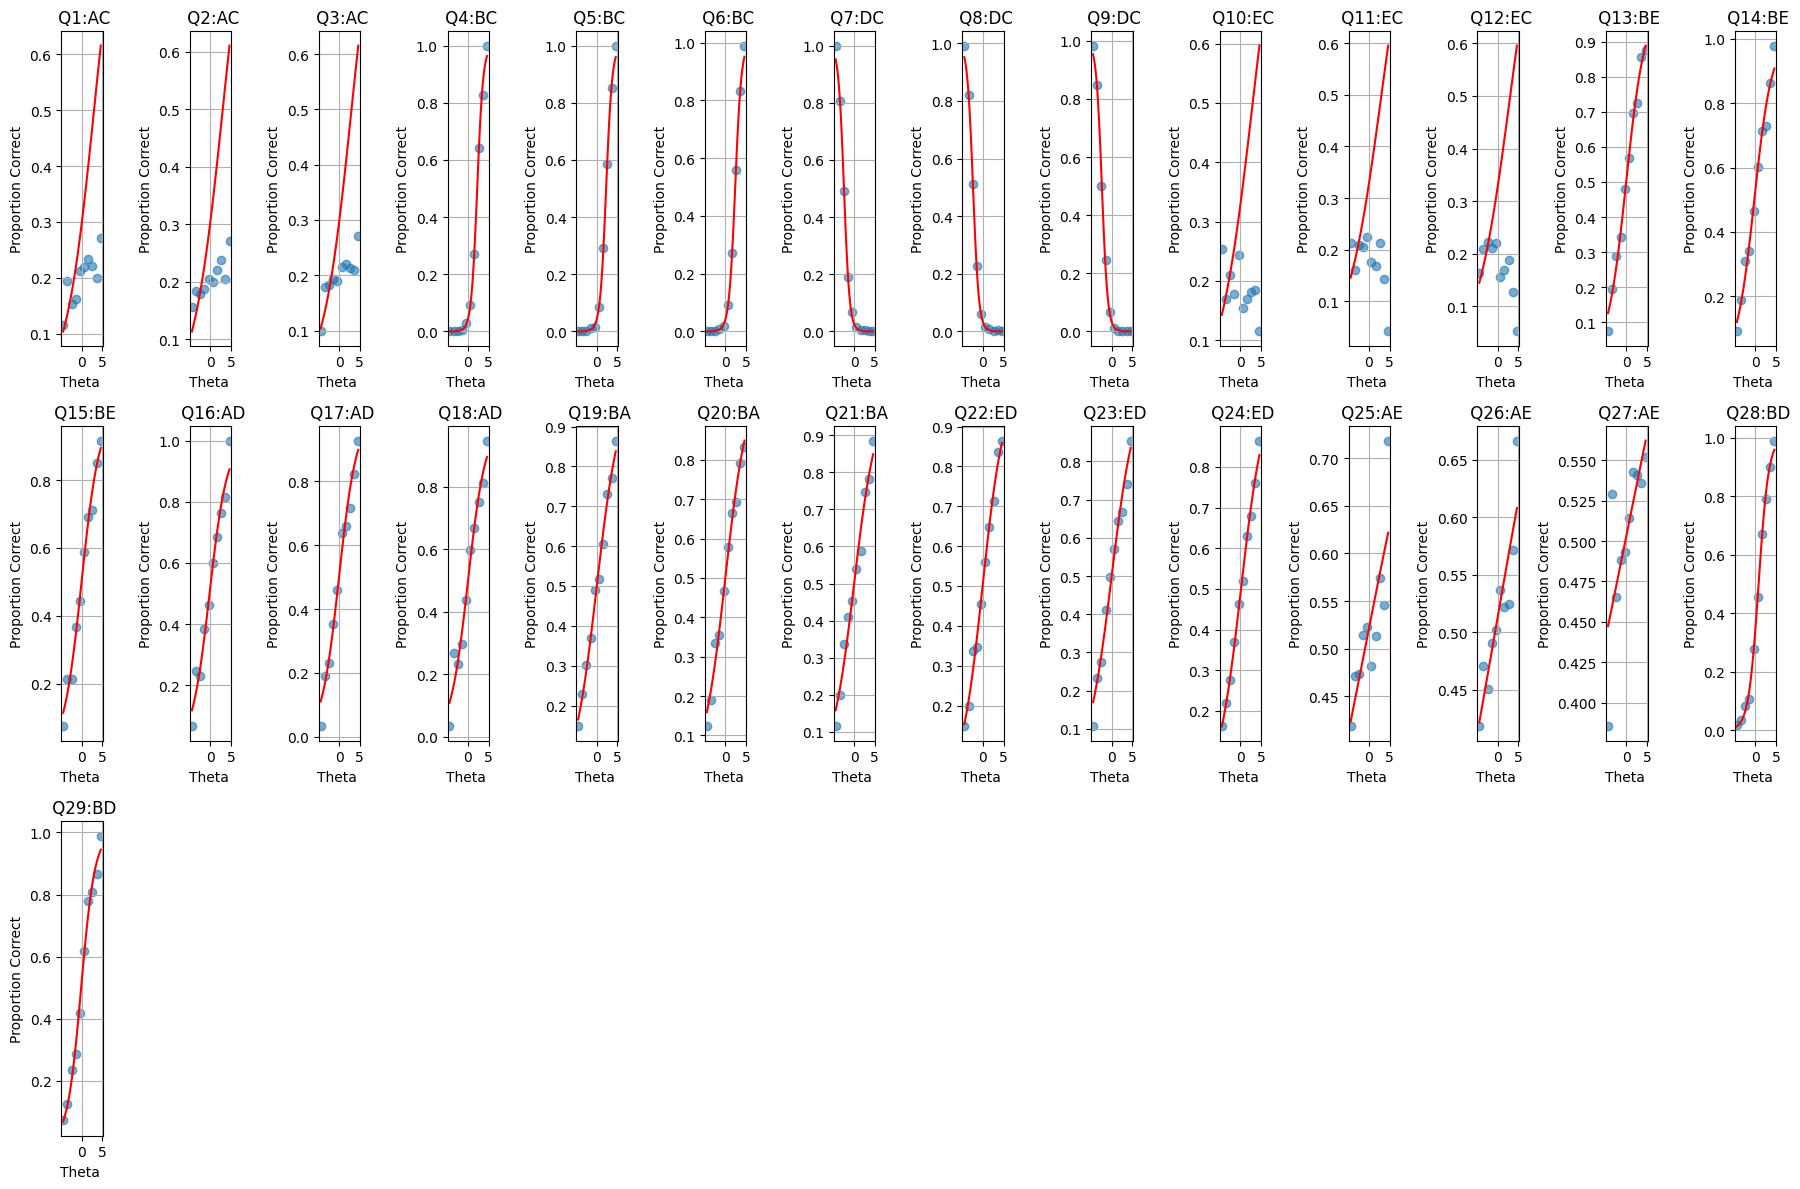


--- PC2に対する推定されたIRTパラメータ (2PL) ---
Q1:AC: a=0.2899, b=3.0000, R²=-18.5491
Q2:AC: a=0.2764, b=3.0000, R²=-35.9050
Q3:AC: a=0.2897, b=3.0000, R²=-19.7963
Q4:BC: a=1.3869, b=2.2637, R²=0.9971
Q5:BC: a=1.3695, b=2.3074, R²=0.9983
Q6:BC: a=1.3274, b=2.3895, R²=0.9985
Q7:DC: a=-1.4806, b=-2.4202, R²=0.9977
Q8:DC: a=-1.4238, b=-2.3439, R²=0.9982
Q9:DC: a=-1.4300, b=-2.3207, R²=0.9973
Q10:EC: a=0.2411, b=3.0000, R²=-36.2491
Q11:EC: a=0.2378, b=3.0000, R²=-23.0789
Q12:EC: a=0.2388, b=3.0000, R²=-25.9200
Q13:BE: a=0.4429, b=-0.0684, R²=0.9903
Q14:BE: a=0.4732, b=-0.2134, R²=0.9834
Q15:BE: a=0.4622, b=-0.0068, R²=0.9872
Q16:AD: a=0.4718, b=-0.1839, R²=0.9741
Q17:AD: a=0.4704, b=-0.0091, R²=0.9789
Q18:AD: a=0.4701, b=0.0555, R²=0.9702
Q19:BA: a=0.3598, b=0.0672, R²=0.9915
Q20:BA: a=0.3738, b=0.0110, R²=0.9874
Q21:BA: a=0.3748, b=0.0251, R²=0.9798
Q22:ED: a=0.3879, b=-0.0355, R²=0.9913
Q23:ED: a=0.3539, b=0.0398, R²=0.9774
Q24:ED: a=0.3558, b=0.1857, R²=0.9949
Q25:AE: a=0.0892, b=-0.9556, R²=0.689

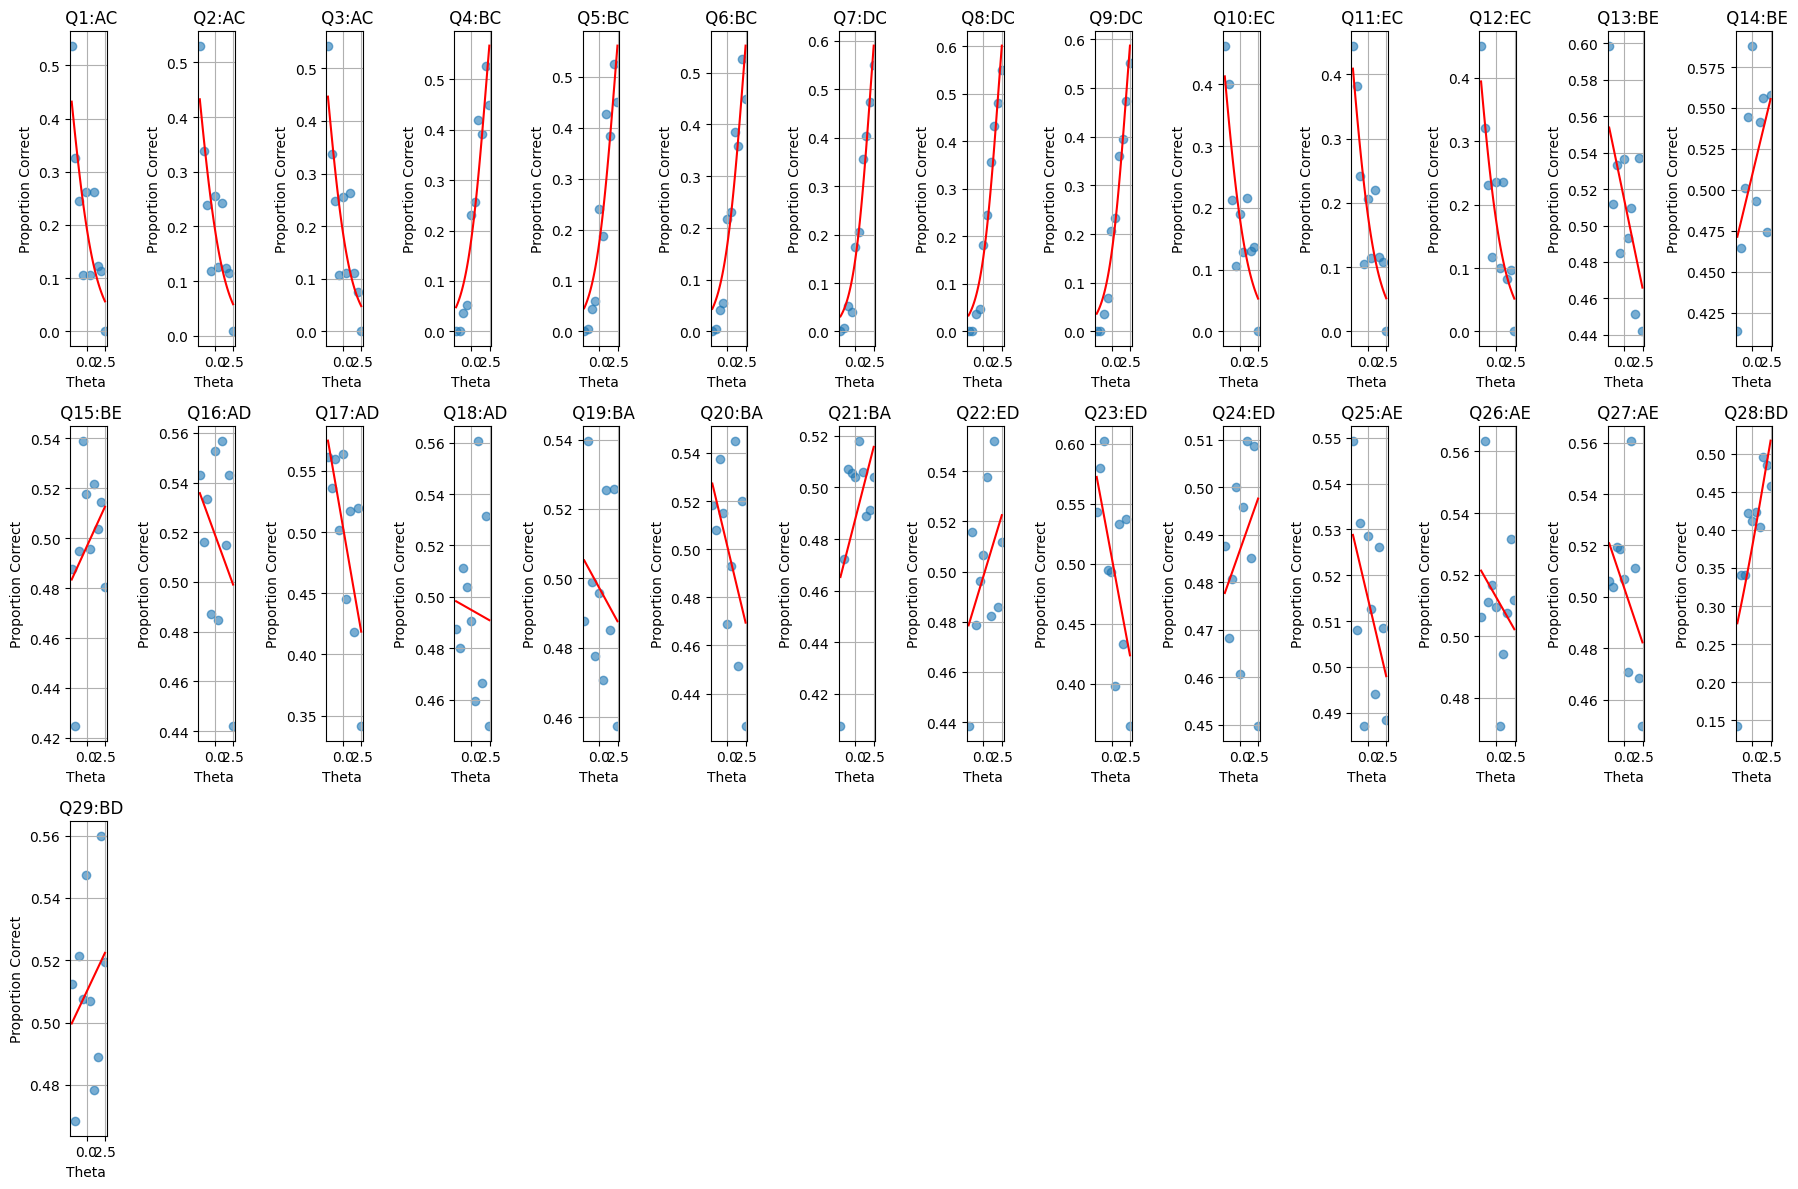


--- PC3に対する推定されたIRTパラメータ (2PL) ---
Q1:AC: a=-0.5714, b=-2.4618, R²=0.6782
Q2:AC: a=-0.5680, b=-2.4580, R²=0.7242
Q3:AC: a=-0.6227, b=-2.3274, R²=0.7211
Q4:BC: a=0.7328, b=2.0976, R²=0.8699
Q5:BC: a=0.7398, b=2.1312, R²=0.8620
Q6:BC: a=0.7416, b=2.1822, R²=0.8905
Q7:DC: a=0.8567, b=2.0380, R²=0.9633
Q8:DC: a=0.8480, b=1.9807, R²=0.9558
Q9:DC: a=0.8163, b=2.0327, R²=0.9584
Q10:EC: a=-0.5688, b=-2.5980, R²=0.7317
Q11:EC: a=-0.5719, b=-2.6274, R²=0.7718
Q12:EC: a=-0.5576, b=-2.7524, R²=0.7508
Q13:BE: a=-0.0793, b=0.7422, R²=0.4187
Q14:BE: a=0.0759, b=-0.4716, R²=0.2812
Q15:BE: a=0.0262, b=0.5478, R²=0.0990
Q16:AD: a=-0.0332, b=2.3366, R²=0.1140
Q17:AD: a=-0.1418, b=0.1458, R²=0.5187
Q18:AD: a=-0.0066, b=-3.0000, R²=-0.0003
Q19:BA: a=-0.0158, b=-0.6617, R²=0.0496
Q20:BA: a=-0.0521, b=0.1164, R²=0.2572
Q21:BA: a=0.0454, b=1.0821, R²=0.2849
Q22:ED: a=0.0396, b=0.1854, R²=0.2101
Q23:ED: a=-0.1347, b=0.1773, R²=0.4152
Q24:ED: a=0.0179, b=3.0000, R²=-0.1194
Q25:AE: a=-0.0278, b=2.1702, R²=0.258

In [16]:
for pc_idx in range(pca_catg.n_components):
    current_theta_scores = theta_pca_catg_scores[:, pc_idx] # 現在の軸のθスコア
    pc_name = f'PC{pc_idx + 1}'
    print(f"\n--- {pc_name}に対するIRT分析 ---")
    # 各軸に対してビンを再計算
    # N=40の場合、num_binsを減らして、各ビンに十分なサンプル数があるように調整することも検討
    # 例えば、num_bins = min(num_subjects // 5, 10) など
    bins = np.linspace(current_theta_scores.min(), current_theta_scores.max(), num_bins + 1)
    theta_bin_centers = (bins[:-1] + bins[1:]) / 2
    item_response_data = [] # (theta_bin_center, item_id, proportion)
    for item_idx in range(num_questions):
        item_responses = binarized_question_data.iloc[:, item_idx]
        bin_proportions = []
        for i in range(num_bins):
            mask = (current_theta_scores >= bins[i]) & (current_theta_scores < bins[i+1])
            if i == num_bins - 1:
                mask = (current_theta_scores >= bins[i]) & (current_theta_scores <= bins[i+1])

            responses_in_bin = item_responses[mask]
            if len(responses_in_bin) > 0:
                proportion = responses_in_bin.mean()
            else:
                proportion = np.nan
            bin_proportions.append(proportion)

        item_response_data.append(bin_proportions)
    item_proportions_df = pd.DataFrame(item_response_data).T
    item_proportions_df.columns = binarized_question_data.columns
    item_proportions_df['theta_bin_center'] = theta_bin_centers
    print("--- θビンごとの正答割合（一部）---")
    print(item_proportions_df.head())



 # --- 4. curve_fitによるパラメータ推定と適合度評価 ---
    estimated_params = {}
    r_squared_values = {}
    plt.figure(figsize=(18, 12)) # 全体像を見やすくするため、図のサイズを大きくする

    for i, q_col in enumerate(binarized_question_data.columns):
     # フィッティングに使うデータポイントを準備
        valid_data = item_proportions_df[[q_col, 'theta_bin_center']].dropna()
        x_data = valid_data['theta_bin_center'].values
        y_data = valid_data[q_col].values
        if len(x_data) > 2: # フィッティングには最低3点必要 (2パラメータ推定のため)
            try:
            # 初期値の設定 (重要): a=1, b=0 は一般的な初期値
            # bounds を設定して、aは正、bは適度な範囲に制限すると安定しやすい
            # a_min=0.01 などで識別力が0にならないようにする
                popt, pcov = curve_fit(logistic_icc, x_data, y_data, p0=[1.0, 0.0],
                                   bounds=([-5.0, -3.0], [5.0, 3.0])) # aの範囲を0.01から5、bの範囲を-3から3に制限

                a_est, b_est = popt
                estimated_params[q_col] = {'a': a_est, 'b': b_est}

            # 適合度 (R-squared) の計算
                y_predicted = logistic_icc(x_data, a_est, b_est)
                ss_res = np.sum((y_data - y_predicted)**2)
                ss_tot = np.sum((y_data - y_data.mean())**2)
                r_squared = 1 - (ss_res / ss_tot)
                r_squared_values[q_col] = r_squared
                #可視化
                plt.subplot(pca_catg.n_components, num_questions // 2, i + 1) # サブプロットの配置を動的に調整
                plt.scatter(x_data, y_data, label='Observed Proportions', alpha=0.6)
                theta_range = np.linspace(x_data.min(), x_data.max(), 100)
                plt.plot(theta_range, logistic_icc(theta_range, a_est, b_est), color='red',
                        label=f'\na={a_est:.2f}, b={b_est:.2f}\nR²={r_squared:.2f}')


                plt.title(f' {q_col}:{question_item_names.get(q_col, "Unknown")}')
                plt.xlabel('Theta ')
                #plt.ylabel('Proportion Correct')
                plt.ylabel('Proportion Correct')
                #plt.legend(fontsize=7)
                plt.grid(True)

            except RuntimeError:
                print(f"Error fitting logistic function for {pc_name} - {q_col}. Skipping.")
                stimated_params[q_col] = {'a': np.nan, 'b': np.nan}
                r_squared_values[q_col] = np.nan
        else:
            print(f"Not enough data points for {q_col}. Skipping.")
            estimated_params[q_col] = {'a': np.nan, 'b': np.nan}
            r_squared_values[q_col] = np.nan

#plt.tight_layout()
#plt.show()
    plt.subplots_adjust(hspace=0.5)
    plt.tight_layout()
    plt.show() # 各PCのループの最後に表示

    # 各PCごとの結果を別途保存または表示すると、後で比較しやすいです
    print(f"\n--- {pc_name}に対する推定されたIRTパラメータ (2PL) ---")
    for q, params in estimated_params.items():
        item_name = question_item_names.get(q, "Unknown")
        print(f"{q}:{item_name}: a={params['a']:.4f}, b={params['b']:.4f}, R²={r_squared_values[q]:.4f}")

    # ここで、各質問がそのPCに対してどの程度寄与しているかを議論できます。
    # 特に、PCAの負荷量とIRTの識別力(a)を比較すると面白いです。
    # 例: print(f"PC{pc_idx + 1}に対するQ{i+1}のPCA負荷量: {pca_loadings.loc[q_col, pc_name]:.4f}")
    # これは、上記PCループの外で、全ての分析結果をまとめて行う方が良いかもしれません。

# --- 各PCに対する最終的な解釈のまとめ ---
print("\n--- 全ての軸に対する最終的な適合度と寄与の解釈 ---")
print("R-squared (決定係数) は、モデルがデータの変動をどの程度説明しているかを示します。")
print("1に近いほど適合度が高いと言えます。")
print("a（識別力）が正で大きいほど、その質問は能力をよく識別しています。")
print("b（困難度）は、その質問に50%の確率で正答する能力水準を示します。")
print("aが負の値やR-squaredが低い質問は、意図した能力を測れていない可能性があります。")
print("\n各質問のPCA負荷量と、各軸に対するIRTのa値とR^2値を比較することで、")
print("質問がどの潜在能力（軸）に強く寄与しているかを判断できます。")


# 全ての推定パラメータをまとめる（オプション）
all_estimated_params = {}
all_r_squared_values = {}
# ... 各PCループ内でestimated_paramsとr_squared_valuesを適切なキーで保存するなどして、ここに集約します。

# print("\n--- 推定されたIRTパラメータ (2PL) ---")
# for q, params in estimated_params.items():
#     print(f"{q}: a={params['a']:.4f}, b={params['b']:.4f}, R²={r_squared_values[q]:.4f}")

# # --- 適合度と寄与の解釈 ---
# print("\n--- 適合度と寄与の解釈 ---")
# print("R-squared (決定係数) は、モデルがデータの変動をどの程度説明しているかを示します。")
# print("1に近いほど適合度が高いと言えます。")
# print("a（識別力）が正で大きいほど、その質問は能力をよく識別しています。")
# print("b（困難度）は、その質問に50%の確率で正答する能力水準を示します。")
# print("aが負の値やR-squaredが低い質問は、意図した能力を測れていない可能性があります。")

In [ ]:
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes
components_catg_2d = components_catg[:, :2]
def calculate_procrustes_similarity(data_a, data_b):
    """
    Procrustes解析を行い、適合度（距離）と変換後のデータを返す関数。
    data_a を data_b に合わせる変換を試みる。
    """
    # Procrustes解析はデータを中心化して行われるため、
    # 並進成分は暗黙的に扱われる（中心間の差）
    # 距離と変換後のデータ (mtx1, mtx2) を取得
    distance, mtx1, mtx2 = procrustes(data_a, data_b)
    # mtx1 は data_a を変換した結果, mtx2 は data_b を変換した結果
    # ここで欲しいのは data_a を data_b に合わせた際の残差（距離）

    # より詳細な適合度（残差平方和）を計算するために、orthogonal_procrustes を使う
    # orthogonal_procrustes は直交行列 R とスケール s を返す
    # data_b_centered = s * (data_a_centered @ R.T)
    # R: data_a_centered を data_b_centered に合わせる回転・反転行列

    # データの中心化
    data_a_centered = data_a - np.mean(data_a, axis=0)
    data_b_centered = data_b - np.mean(data_b, axis=0)

    # orthogonal_procrustes を使用して回転行列とスケールを推定
    # R: data_a_centered を data_b_centered に変換する直交行列（回転と反転）
    # scale: data_a_centered のスケールを data_b_centered に合わせるスケールファクター
    R, scale = orthogonal_procrustes(data_b_centered, data_a_centered)

    # 推定された変換を適用した後の data_a
    transformed_a_for_comparison = scale * (data_a_centered @ R.T)

    # 残差平方和 (Sum of Squared Differences) を計算
    # これが適合度の指標となる。小さいほど適合している。
    ssd = np.sum((transformed_a_for_comparison - data_b_centered)**2)

    return ssd, R, scale # 残差平方和、回転行列、スケールを返す

In [ ]:
# --- ケース1: 反転なしで適合度を計算 ---
filtering_radius = 0.15
distances_from_center = np.linalg.norm(user_theta_coords, axis=1)
indices_to_include = np.where(distances_from_center <= filtering_radius)[0]
filtered_user_theta_coords = user_theta_coords[indices_to_include]
filtered_components_2d = components_catg_2d[indices_to_include]
print("--- ケース1: 反転なしの場合の適合度計算 ---")
ssd_no_flip, R_no_flip, scale_no_flip = calculate_procrustes_similarity(filtered_components_2d, filtered_user_theta_coords)
estimated_rotation_deg_no_flip = np.degrees(np.arctan2(R_no_flip[1, 0], R_no_flip[0, 0]))
print(f"残差平方和 (SSD, 反転なし): {ssd_no_flip:.4f}")
print(f"推定回転角 (反転なし): {estimated_rotation_deg_no_flip:.2f} 度")
print(f"推定スケール (反転なし): {scale_no_flip:.4f}")

# --- ケース2: X軸反転を仮定して適合度を計算 ---
print("\n--- ケース2: X軸反転を仮定した場合の適合度計算 ---")
components_2d_flipped_x = filtered_components_2d.copy()
components_2d_flipped_x[:, 0] *= -1 # X軸反転を適用

ssd_flipped_x, R_flipped_x, scale_flipped_x = calculate_procrustes_similarity(components_2d_flipped_x, filtered_user_theta_coords)
estimated_rotation_deg_flipped_x = np.degrees(np.arctan2(R_flipped_x[1, 0], R_flipped_x[0, 0]))
print(f"残差平方和 (SSD, X軸反転): {ssd_flipped_x:.4f}")
print(f"推定回転角 (X軸反転): {estimated_rotation_deg_flipped_x:.2f} 度")
print(f"推定スケール (X軸反転): {scale_flipped_x:.4f}")

# --- Y軸反転も比較したい場合 ---
# components_2d_flipped_y = components_2d.copy()
# components_2d_flipped_y[:, 1] *= -1 # Y軸反転を適用
# ssd_flipped_y, R_flipped_y, scale_flipped_y = calculate_procrustes_similarity(components_2d_flipped_y, user_theta_coords)
# estimated_rotation_deg_flipped_y = np.degrees(np.arctan2(R_flipped_y[1, 0], R_flipped_y[0, 0]))
# print(f"\n残差平方和 (SSD, Y軸反転): {ssd_flipped_y:.4f}")
# print(f"推定回転角 (Y軸反転): {estimated_rotation_deg_flipped_y:.2f} 度")
# print(f"推定スケール (Y軸反転): {scale_flipped_y:.4f}")

# --- 最も適合度の高い変換を選択 ---
print("\n--- 最終結果 ---")
if ssd_no_flip <= ssd_flipped_x: # and (ssd_flipped_y is None or ssd_no_flip <= ssd_flipped_y):
    print(f"反転なしのケースがより良く適合します。")
    print(f"最適な推定回転角: {estimated_rotation_deg_no_flip:.2f} 度")
    print(f"最適な推定拡大率: {scale_no_flip:.4f}")
    print(f"Procrustes変換行列 (反転なし): \n{R_no_flip}")
    transformed_components_aligned = 1/3 * (components_catg_2d @ R_no_flip.T)
else: # if ssd_flipped_x < ssd_no_flip:
    print(f"X軸反転のケースがより良く適合します。")
    print(f"最適な推定回転角: {estimated_rotation_deg_flipped_x:.2f} 度")
    print(f"最適な推定拡大率: {scale_flipped_x:.4f}")
    print(f"Procrustes変換行列 (X軸反転): \n{R_flipped_x}")
    transformed_components_aligned = 1/3 * (components_catg_2d @ R_flipped_x.T)
    print("この変換行列は、元のデータにX軸反転を適用した上で、user_theta_coordsに合わせる回転を表します。")
    print("よって、元のデータはまずX軸反転し、その後この行列で回転・拡大するとuser_theta_coordsに近くなります。")

--- ケース1: 反転なしの場合の適合度計算 ---
残差平方和 (SSD, 反転なし): 0.0190
推定回転角 (反転なし): 148.82 度
推定スケール (反転なし): 0.0826

--- ケース2: X軸反転を仮定した場合の適合度計算 ---
残差平方和 (SSD, X軸反転): 0.0190
推定回転角 (X軸反転): -31.18 度
推定スケール (X軸反転): 0.0826

--- 最終結果 ---
反転なしのケースがより良く適合します。
最適な推定回転角: 148.82 度
最適な推定拡大率: 0.0826
Procrustes変換行列 (反転なし): 
[[-0.85557613 -0.51767701]
 [ 0.51767701 -0.85557613]]


ビジュアライズ

user_theta_coords の形状: (100, 2)
components の形状: (100, 3)


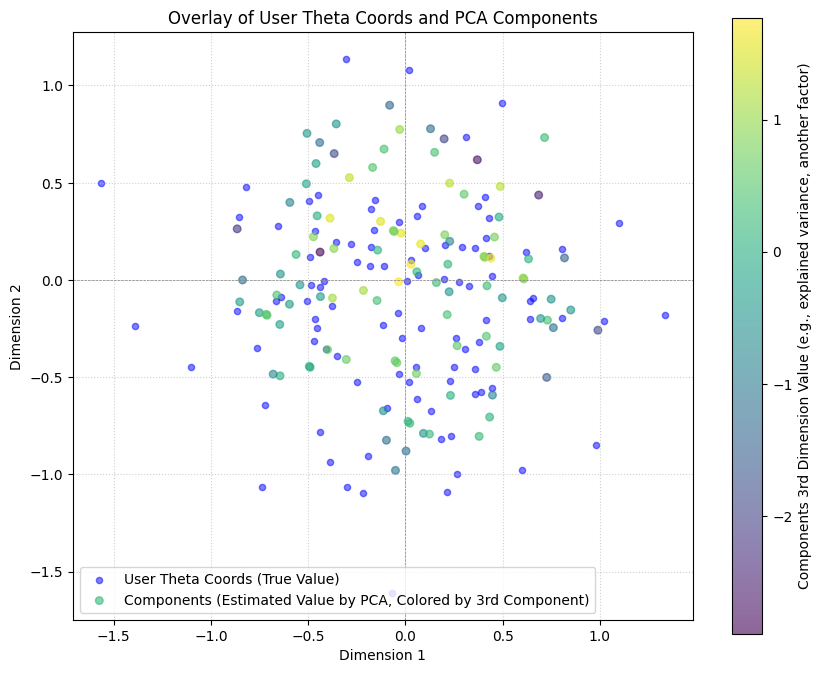

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # ダミーデータ生成のために使用

# --- 1. ダミーデータの生成 (実際のデータに置き換えてください) ---
#NUM_USERS = 2000


# components (推定値、3次元)
# 例として、user_theta_coords に変換とノイズを加えて components を生成し、
# 第3成分は他の要素と関連があるか、あるいは独立したノイズと仮定します。
# ここでは、第3成分がランダムな値を持つようにします。


print(f"user_theta_coords の形状: {user_theta_coords.shape}")
print(f"components の形状: {components_catg.shape}")

# --- 2. プロットに必要なデータの抽出 ---
components_2d_xy = transformed_components_aligned # components の最初の2次元 (X, Y座標)
components_color_data = components_catg[:, 2] # components の第3成分 (色に使用)

# --- 3. 2次元上に重ねてプロット ---
plt.figure(figsize=(10, 8))

# user_theta_coords をプロット (青い点)
plt.scatter(user_theta_coords[:, 0], user_theta_coords[:, 1],
            color='blue', alpha=0.5, s=20, label='User Theta Coords (True Value)')

# components の最初の2次元をプロットし、第3成分で色付け
# `c` 引数に色のデータを渡し、`cmap` でカラーマップを指定します。
# `s` は点のサイズ、`alpha` は透明度です。
scatter = plt.scatter(components_2d_xy[:, 0], components_2d_xy[:, 1],
                      c=components_color_data, cmap='viridis', alpha=0.6, s=30,
                      label='Components (Estimated Value by PCA, Colored by 3rd Component)')

# カラーバーの追加 (第3成分の値を視覚的に示すため)
cbar = plt.colorbar(scatter)
cbar.set_label('Components 3rd Dimension Value (e.g., explained variance, another factor)')

# --- 4. ラベルとタイトルの追加 ---
plt.title('Overlay of User Theta Coords and PCA Components')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5) # X軸
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5) # Y軸
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box') # アスペクト比を1:1に設定して歪みを防ぐ

# --- 5. プロットの表示 ---
plt.show()

d1 の形状: (100, 2)
d2 の形状: (100, 2)


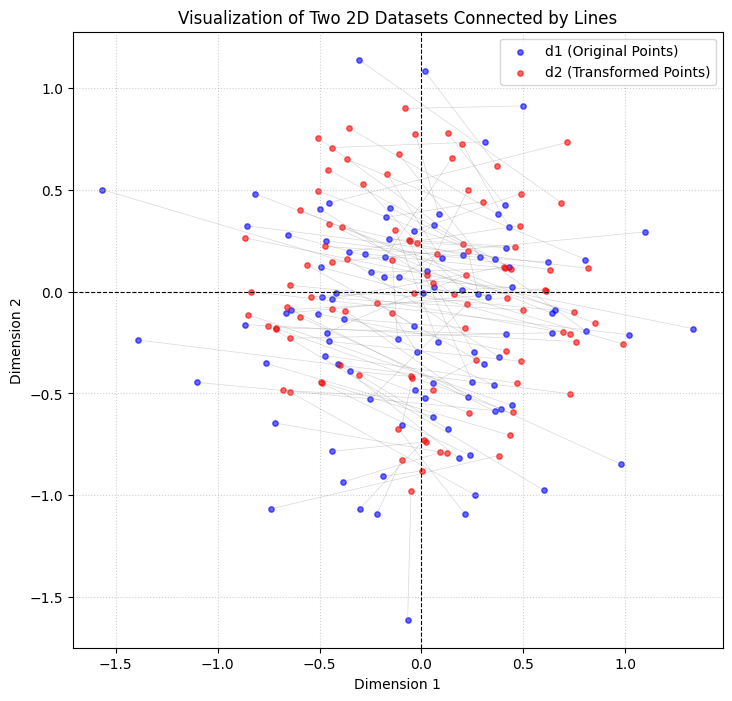

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
N=NUM_USERS
# import numpy as np
# import matplotlib.pyplot as plt

# # --- 1. ダミーデータの生成 (N=2000) ---
# # 実際の d1, d2 データに置き換えてください。
# # ここでは、d1 を円状に配置し、d2 を d1 から少しずらして生成します。
# N = 2000
# theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
# r_d1 = 1.0 # d1 の半径
d1 = user_theta_coords

# # d2 を d1 から少し回転・拡大・ノイズを加える
# rotation_angle = np.pi / 6 # 30度回転
# scale_factor = 1.2
# noise_level = 0.1

# rotation_matrix = np.array([
#     [np.cos(rotation_angle), -np.sin(rotation_angle)],
#     [np.sin(rotation_angle), np.cos(rotation_angle)]
# ])

d2 =transformed_components_aligned

print(f"d1 の形状: {d1.shape}")
print(f"d2 の形状: {d2.shape}")

# --- 2. データの可視化 ---
plt.figure(figsize=(10, 8))

# d1 の点をプロット
plt.scatter(d1[:, 0], d1[:, 1], color='blue', alpha=0.6, s=15, label='d1 (Original Points)')

# d2 の点をプロット
plt.scatter(d2[:, 0], d2[:, 1], color='red', alpha=0.6, s=15, label='d2 (Transformed Points)')

# d1 の各点から d2 の対応する点へ線を引く
# 各点を順番に結ぶのではなく、対応する (d1[i], d2[i]) のペアを結びます。
for i in range(N):
    plt.plot([d1[i, 0], d2[i, 0]], [d1[i, 1], d2[i, 1]],
             color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

# --- 3. グラフの装飾 ---
plt.title('Visualization of Two 2D Datasets Connected by Lines')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # X軸
plt.axvline(0, color='black', linestyle='--', linewidth=0.8) # Y軸
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box') # アスペクト比を1:1に設定
#ax.view_init(elev=20, azim=45)
plt.show()

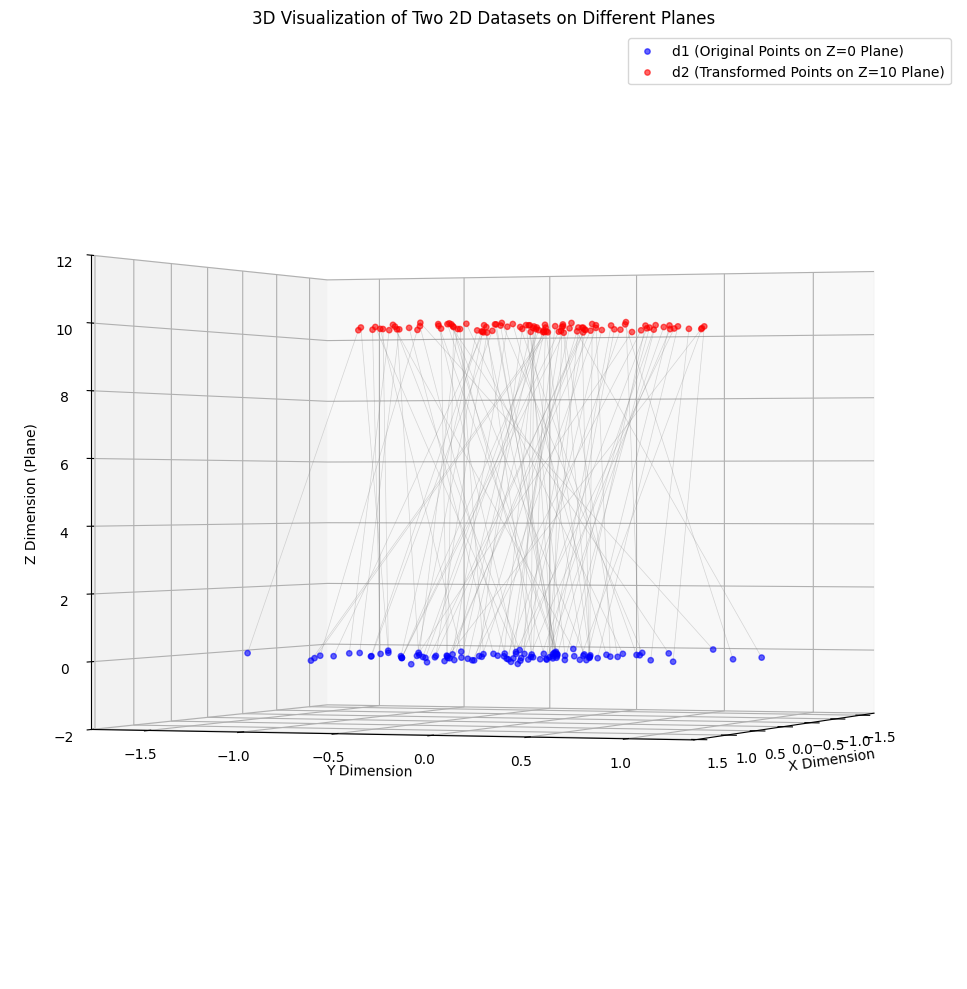

In [ ]:
# --- 2. 各データセットを配置するZ座標の定義 ---
z_d1_plane = 0   # d1 は Z=0 の平面に配置
z_d2_plane = 10  # d2 は Z=10 の平面に配置 (任意の異なる値)

# --- 3. 3Dプロットの作成 ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d') # 3Dプロジェクションを設定

# --- 4. d1 の点を3D空間にプロット ---
# X, Y は d1 の座標、Z は定義した z_d1_plane
ax.view_init(elev=0, azim=20)
ax.scatter(d1[:, 0], d1[:, 1], z_d1_plane,
           color='blue', alpha=0.6, s=15, label='d1 (Original Points on Z=0 Plane)')

# --- 5. d2 の点を3D空間にプロット ---
# X, Y は d2 の座標、Z は定義した z_d2_plane
ax.scatter(d2[:, 0], d2[:, 1], z_d2_plane,
           color='red', alpha=0.6, s=15, label='d2 (Transformed Points on Z=10 Plane)')

# --- 6. d1 の各点から d2 の対応する点へ3D空間で線を引く ---
for i in range(N):
    ax.plot([d1[i, 0], d2[i, 0]],
            [d1[i, 1], d2[i, 1]],
            [z_d1_plane, z_d2_plane], # Z座標も線で結ぶ
            color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

# --- 7. グラフの装飾 ---
ax.set_title('3D Visualization of Two 2D Datasets on Different Planes')
ax.set_xlabel('X Dimension')
ax.set_ylabel('Y Dimension')
ax.set_zlabel('Z Dimension (Plane)') # Z軸のラベルを設定

# Z軸の範囲を調整して平面が視認しやすいようにする
ax.set_zlim(min(z_d1_plane, z_d2_plane) - 2, max(z_d1_plane, z_d2_plane) + 2)

ax.legend()
plt.tight_layout() # レイアウトを調整

# --- 8. プロットの表示 ---
plt.show()